# Tiny ViT Loss Landscape: Raw Weights vs BigVAE Latents

This notebook supports multiple tiny ViT tasks while keeping both parameterizations:

1. **Raw weights**: direct filter-wise normalized perturbations of the trained tiny ViT weights.
2. **BigVAE latents**: optional perturbations in frozen BigVAE latent slots, decoded back into the tiny ViT's 2D linear weights.

Configured tasks:

- `stripe_parity`: synthetic 16x16 grayscale stripe-parity task.
- `mnist`: MNIST resized to `cfg.image_size`.
- `cifar10`: CIFAR-10 resized to `cfg.image_size`.

The synthetic stripe-parity task uses patch size 4, so the ViT receives 16 patch tokens. Each patch independently contains vertical or horizontal stripes. Per-patch random noise, contrast, brightness, and slight phase jitter make it nontrivial local pattern recognition. A fixed subset `S` of 8 patch positions defines the binary label by parity/XOR:
  `y = sum(bits[S]) mod 2`.

The raw-weight landscape is intentionally hostile: XOR over 8 local patch types creates a high-order interaction, the dataset is small, and good solutions tend to be sharp. The notebook also exposes flat-parameter helpers for evaluating arbitrary raw perturbations.

Both raw and latent sections render the existing 2D contour plot plus an interactive Plotly 3D surface that can be rotated in the notebook.


In [1]:
from __future__ import annotations

import itertools
import math
import random
import time
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

try:
    from torch.func import functional_call
except Exception:
    from torch.nn.utils.stateless import functional_call

import matplotlib.pyplot as plt
from IPython.display import display

try:
    from torchvision import datasets, transforms
except Exception as exc:
    datasets = None
    transforms = None
    print('torchvision imports unavailable; MNIST/CIFAR-10 tasks will not work:', repr(exc))

try:
    import plotly.graph_objects as go
except Exception:
    go = None

try:
    from omegaconf import OmegaConf
    from big_vae.datasets.offline import infer_layer_depth, infer_layer_type
    from training.big_vae.runtime import _build_model_cfg
    from training.big_vae.checkpointing import _normalize_model_state_dict_keys
    from big_vae.models import BigWeightVAE, build_weight_quantile_vae
    from training.big_vae_latent_diffusion import (
        build_cond_global_from_dist_var_pooled,
        build_layer_metadata_condition_vector,
        latent_diffusion_layer_type_to_id,
        load_distribution_encoder_state_from_latent_diffusion_prior_checkpoint,
        load_frozen_layer_latent_diffusion_prior,
    )
except Exception as exc:
    OmegaConf = None
    BigWeightVAE = None
    build_weight_quantile_vae = None
    infer_layer_depth = None
    infer_layer_type = None
    _build_model_cfg = None
    _normalize_model_state_dict_keys = None
    build_cond_global_from_dist_var_pooled = None
    build_layer_metadata_condition_vector = None
    latent_diffusion_layer_type_to_id = None
    load_distribution_encoder_state_from_latent_diffusion_prior_checkpoint = None
    load_frozen_layer_latent_diffusion_prior = None
    print('BigVAE imports unavailable; raw-weight landscape still works:', repr(exc))

try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

plt.rcParams['figure.dpi'] = 120


@dataclass
class Config:
    seed: int = 42
    device: str = 'cuda:1' if torch.cuda.is_available() else 'cpu'

    # Task: stripe_parity | mnist | cifar10.
    task_name: str = 'mnist'
    data_dir: str = './data'
    image_size: int = 16
    patch_size: int = 4
    image_channels: int = 1
    parity_subset: tuple[int, ...] = (0, 2, 5, 7, 8, 10, 13, 15)
    train_samples: int = 1024
    val_samples: int = 1024
    batch_size: int = 128
    eval_batch_size: int = 256
    num_workers: int = 0
    noise_std: float = 0.12
    contrast_min: float = 0.65
    contrast_max: float = 1.35
    brightness_jitter: float = 0.25
    phase_jitter_pixels: float = 0.35

    # Tiny ViT.
    hidden_dim: int = 48
    num_heads: int = 4
    num_vit_layers: int = 2
    mlp_ratio: float = 8.0
    num_classes: int = 10

    # Training. More epochs are intentional: parity is hard for a tiny shallow ViT.
    train_epochs: int = 1000
    train_lr: float = 3e-4
    train_weight_decay: float = 1e-4
    grad_clip_norm: float = 1.0

    # Landscape grid.
    num_directions: int = 4
    grid_points: int = 62
    rho_max: float = 2.0
    landscape_split: str = 'train'  # train | val
    landscape_max_batches: int = 4  # 0 means full selected landscape loader for every grid point.
    rho_values: tuple[float, ...] = (0.25, 0.5, 0.75, 1.0)
    tau_values: tuple[float, ...] = (0.01, 0.05, 0.1)

    # Optional BigVAE latent landscapes.
    # Legacy fallback: if the explicit AE/VAE checkpoint is empty, the corresponding path falls back to big_vae_checkpoint.
    # Leave all of them empty to run raw-only.
    big_vae_checkpoint: str = '/home/coder/project/artifacts/training/checkpoints/weight_quantile_vae_gpu0_square/stage_1/latest.pt'
    big_vae_ae_checkpoint: str = '/home/coder/project/artifacts/training/checkpoints/weight_quantile_vae_gpu0_square/stage_1/latest.pt'
    big_vae_vae_checkpoint: str = '/home/coder/project/artifacts/training/checkpoints/weight_quantile_vae_gpu0_square_VAE/stage_1/latest.pt'
    big_vae_tile_T_patches: int = 4
    big_vae_tile_d_out: int = 64
    big_vae_latent_init: str = 'random'  # random | base
    latent_base_mode: str = 'encoder'  # encoder | fit | encoder_fit | random
    latent_fit_steps: int = 0
    latent_fit_lr: float = 1e-1
    latent_task_train_steps: int = 1600
    latent_task_lr: float = 1e-1
    latent_task_weight_decay: float = 0.0
    latent_task_grad_clip_norm: float = 1.0
    latent_task_log_every: int = 50
    latent_ae_landscape_enabled: bool = True
    latent_vae_landscape_enabled: bool = True
    latent_diffusion_prior_checkpoint: str = '/home/coder/project/artifacts/training/checkpoints/big_vae_latent_diffusion_prior_AE/stage_1/latest.pt'
    latent_diffusion_prior_steps: int = 100
    latent_diffusion_prior_sampler: str = 'ddim'
    latent_diffusion_prior_eta: float = 0.0
    latent_diffusion_prior_calibration_batches: int = 4

    # Latent transfer: optimize from the primary task latent solution on the two other tasks,
    # then project the found solutions onto the primary latent landscape plane.
    latent_transfer_enabled: bool = True
    latent_transfer_tasks: tuple[str, ...] = ()  # Empty -> all tasks except cfg.task_name.
    latent_transfer_train_steps: int = 1600
    latent_transfer_lr: float = 1e-1
    latent_transfer_weight_decay: float = 0.0
    latent_transfer_grad_clip_norm: float = 1.0
    latent_transfer_log_every: int = 50
    latent_transfer_label_mode: str = 'mod'  # mod | error when transfer labels exceed cfg.num_classes.

    encoder_context_batches: int = 4
    encoder_context_rows: int = 1024
    artifact_dir: str = './artifacts/loss_landscape_diffusion'


cfg = Config()
BIG_VAE_AE_CHECKPOINT = str(cfg.big_vae_ae_checkpoint).strip() or str(cfg.big_vae_checkpoint).strip()
BIG_VAE_VAE_CHECKPOINT = str(cfg.big_vae_vae_checkpoint).strip() or str(cfg.big_vae_checkpoint).strip()
device = torch.device(cfg.device)
artifact_dir = Path(cfg.artifact_dir)
artifact_dir.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(cfg.seed)
valid_task_names = {'stripe_parity', 'mnist', 'cifar10'}
cfg.task_name = str(cfg.task_name).strip().lower()
if cfg.task_name not in valid_task_names:
    raise ValueError(f'cfg.task_name must be stripe_parity, mnist, or cifar10, got {cfg.task_name!r}')
cfg.latent_transfer_tasks = tuple(str(task).strip().lower() for task in cfg.latent_transfer_tasks)
unknown_transfer_tasks = sorted(set(cfg.latent_transfer_tasks) - valid_task_names)
if unknown_transfer_tasks:
    raise ValueError(f'cfg.latent_transfer_tasks contains unsupported tasks: {unknown_transfer_tasks}')
cfg.latent_transfer_label_mode = str(cfg.latent_transfer_label_mode).strip().lower()
if cfg.latent_transfer_label_mode not in {'mod', 'error'}:
    raise ValueError(f'cfg.latent_transfer_label_mode must be mod or error, got {cfg.latent_transfer_label_mode!r}')
if cfg.task_name == 'stripe_parity':
    cfg.image_channels = 1
    cfg.num_classes = 2
elif cfg.task_name == 'mnist':
    cfg.image_channels = 1
    cfg.num_classes = 10
elif cfg.task_name == 'cifar10':
    cfg.image_channels = 3
    cfg.num_classes = 10
assert cfg.image_size % cfg.patch_size == 0
assert cfg.hidden_dim % cfg.num_heads == 0
assert int(cfg.num_vit_layers) >= 1
if cfg.task_name == 'stripe_parity':
    assert len(cfg.parity_subset) == 8
    assert len(set(cfg.parity_subset)) == len(cfg.parity_subset)
    assert min(cfg.parity_subset) >= 0
    assert max(cfg.parity_subset) < (cfg.image_size // cfg.patch_size) ** 2

print(cfg)
print('device =', device)


Config(seed=42, device='cuda:1', task_name='mnist', data_dir='./data', image_size=16, patch_size=4, image_channels=1, parity_subset=(0, 2, 5, 7, 8, 10, 13, 15), train_samples=1024, val_samples=1024, batch_size=128, eval_batch_size=256, num_workers=0, noise_std=0.12, contrast_min=0.65, contrast_max=1.35, brightness_jitter=0.25, phase_jitter_pixels=0.35, hidden_dim=48, num_heads=4, num_vit_layers=2, mlp_ratio=8.0, num_classes=10, train_epochs=1000, train_lr=0.0003, train_weight_decay=0.0001, grad_clip_norm=1.0, num_directions=4, grid_points=62, rho_max=2.0, landscape_split='train', landscape_max_batches=4, rho_values=(0.25, 0.5, 0.75, 1.0), tau_values=(0.01, 0.05, 0.1), big_vae_checkpoint='/home/coder/project/artifacts/training/checkpoints/weight_quantile_vae_gpu0_square/stage_1/latest.pt', big_vae_ae_checkpoint='/home/coder/project/artifacts/training/checkpoints/weight_quantile_vae_gpu0_square/stage_1/latest.pt', big_vae_vae_checkpoint='/home/coder/project/artifacts/training/checkpoints

train batches: 8 val batches: 4
label balance train: [100, 120, 101, 95, 108, 92, 95, 122, 90, 101]
label balance val: [87, 130, 118, 108, 113, 89, 89, 102, 91, 97]


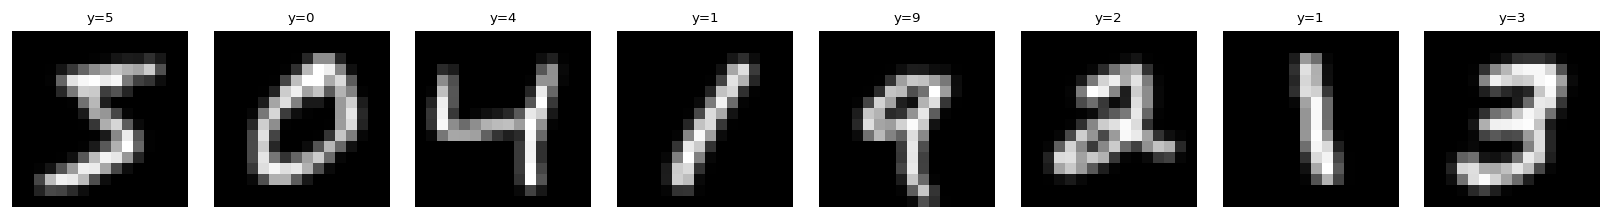

In [2]:
def generate_stripe_parity_dataset(
    num_samples: int,
    cfg: Config,
    *,
    seed: int,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Generate images, labels, and underlying patch-type bits.

    bits[:, p] = 0 means vertical stripes in patch p.
    bits[:, p] = 1 means horizontal stripes in patch p.
    Patch positions are row-major over the 4x4 patch grid.
    """
    generator = torch.Generator(device='cpu')
    generator.manual_seed(int(seed))

    patch_size = int(cfg.patch_size)
    grid_size = int(cfg.image_size // cfg.patch_size)
    num_patches = grid_size * grid_size

    bits = torch.randint(0, 2, (num_samples, num_patches), generator=generator, dtype=torch.long)
    labels = (bits[:, list(cfg.parity_subset)].sum(dim=1) % 2).long()
    images = torch.empty(num_samples, 1, cfg.image_size, cfg.image_size, dtype=torch.float32)

    yy, xx = torch.meshgrid(
        torch.arange(patch_size, dtype=torch.float32),
        torch.arange(patch_size, dtype=torch.float32),
        indexing='ij',
    )
    xx = xx.unsqueeze(0)
    yy = yy.unsqueeze(0)

    for patch_idx in range(num_patches):
        row = patch_idx // grid_size
        col = patch_idx % grid_size
        y0 = row * patch_size
        x0 = col * patch_size

        phase = (torch.rand(num_samples, 1, 1, generator=generator) * 2.0 - 1.0) * float(cfg.phase_jitter_pixels)
        contrast = float(cfg.contrast_min) + (float(cfg.contrast_max) - float(cfg.contrast_min)) * torch.rand(
            num_samples,
            1,
            1,
            generator=generator,
        )
        brightness = (torch.rand(num_samples, 1, 1, generator=generator) * 2.0 - 1.0) * float(cfg.brightness_jitter)

        vertical = torch.cos(math.pi * (xx + phase))
        horizontal = torch.cos(math.pi * (yy + phase))
        is_horizontal = bits[:, patch_idx].view(num_samples, 1, 1).bool()
        pattern = torch.where(is_horizontal, horizontal, vertical)
        noise = float(cfg.noise_std) * torch.randn(num_samples, patch_size, patch_size, generator=generator)
        patch = contrast * pattern + brightness + noise

        images[:, 0, y0:y0 + patch_size, x0:x0 + patch_size] = patch

    return images, labels, bits


def normalize_from_train(
    train_images: torch.Tensor,
    val_images: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    train_mean = train_images.mean(dim=(0, 2, 3), keepdim=True)
    train_std = train_images.std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    return (train_images - train_mean) / train_std, (val_images - train_mean) / train_std, train_mean, train_std


def make_tensor_loaders(
    cfg: Config,
    train_images: torch.Tensor,
    train_labels: torch.Tensor,
    val_images: torch.Tensor,
    val_labels: torch.Tensor,
    *,
    train_bits: torch.Tensor | None = None,
    val_bits: torch.Tensor | None = None,
):
    train_images, val_images, train_mean, train_std = normalize_from_train(train_images, val_images)
    pin_memory = device.type == 'cuda'
    train_loader = DataLoader(
        TensorDataset(train_images, train_labels),
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        TensorDataset(val_images, val_labels),
        batch_size=cfg.eval_batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
    )
    data_info = {
        'train_images': train_images,
        'train_labels': train_labels,
        'val_images': val_images,
        'val_labels': val_labels,
        'task_name': cfg.task_name,
        'train_mean': train_mean,
        'train_std': train_std,
    }
    if train_bits is not None:
        data_info['train_bits'] = train_bits
    if val_bits is not None:
        data_info['val_bits'] = val_bits
    return train_loader, val_loader, data_info


def make_stripe_parity_loaders(cfg: Config):
    train_images, train_labels, train_bits = generate_stripe_parity_dataset(cfg.train_samples, cfg, seed=cfg.seed + 1)
    val_images, val_labels, val_bits = generate_stripe_parity_dataset(cfg.val_samples, cfg, seed=cfg.seed + 2)
    return make_tensor_loaders(
        cfg,
        train_images,
        train_labels,
        val_images,
        val_labels,
        train_bits=train_bits,
        val_bits=val_bits,
    )


def materialize_torchvision_subset(dataset, num_samples: int) -> tuple[torch.Tensor, torch.Tensor]:
    count = min(int(num_samples), len(dataset))
    images = []
    labels = []
    for idx in range(count):
        image, label = dataset[idx]
        images.append(image)
        labels.append(int(label))
    return torch.stack(images, dim=0).to(dtype=torch.float32), torch.tensor(labels, dtype=torch.long)


def make_torchvision_loaders(cfg: Config):
    if datasets is None or transforms is None:
        raise RuntimeError('torchvision is required for task_name=mnist or task_name=cifar10')
    transform = transforms.Compose([
        transforms.Resize((int(cfg.image_size), int(cfg.image_size))),
        transforms.ToTensor(),
    ])
    if cfg.task_name == 'mnist':
        train_set = datasets.MNIST(root=cfg.data_dir, train=True, download=True, transform=transform)
        val_set = datasets.MNIST(root=cfg.data_dir, train=False, download=True, transform=transform)
    elif cfg.task_name == 'cifar10':
        train_set = datasets.CIFAR10(root=cfg.data_dir, train=True, download=True, transform=transform)
        val_set = datasets.CIFAR10(root=cfg.data_dir, train=False, download=True, transform=transform)
    else:
        raise ValueError(f'unsupported torchvision task {cfg.task_name!r}')
    train_images, train_labels = materialize_torchvision_subset(train_set, cfg.train_samples)
    val_images, val_labels = materialize_torchvision_subset(val_set, cfg.val_samples)
    return make_tensor_loaders(cfg, train_images, train_labels, val_images, val_labels)


def make_task_loaders(cfg: Config):
    if cfg.task_name == 'stripe_parity':
        return make_stripe_parity_loaders(cfg)
    if cfg.task_name in {'mnist', 'cifar10'}:
        return make_torchvision_loaders(cfg)
    raise ValueError(f'unsupported cfg.task_name={cfg.task_name!r}')


def task_config_for_name(base_cfg: Config, task_name: str) -> Config:
    task_name = str(task_name).strip().lower()
    if task_name not in {'stripe_parity', 'mnist', 'cifar10'}:
        raise ValueError(f'unsupported task_name={task_name!r}')
    task_cfg = replace(base_cfg)
    task_cfg.task_name = task_name
    if task_name == 'stripe_parity':
        task_cfg.image_channels = 1
        task_cfg.num_classes = 2
    elif task_name == 'mnist':
        task_cfg.image_channels = 1
        task_cfg.num_classes = 10
    elif task_name == 'cifar10':
        task_cfg.image_channels = 3
        task_cfg.num_classes = 10
    return task_cfg


def materialize_task_tensors(task_cfg: Config):
    if task_cfg.task_name == 'stripe_parity':
        train_images, train_labels, train_bits = generate_stripe_parity_dataset(
            task_cfg.train_samples,
            task_cfg,
            seed=task_cfg.seed + 1,
        )
        val_images, val_labels, val_bits = generate_stripe_parity_dataset(
            task_cfg.val_samples,
            task_cfg,
            seed=task_cfg.seed + 2,
        )
        return train_images, train_labels, val_images, val_labels, train_bits, val_bits

    if datasets is None or transforms is None:
        raise RuntimeError('torchvision is required for task_name=mnist or task_name=cifar10')
    transform = transforms.Compose([
        transforms.Resize((int(task_cfg.image_size), int(task_cfg.image_size))),
        transforms.ToTensor(),
    ])
    if task_cfg.task_name == 'mnist':
        train_set = datasets.MNIST(root=task_cfg.data_dir, train=True, download=True, transform=transform)
        val_set = datasets.MNIST(root=task_cfg.data_dir, train=False, download=True, transform=transform)
    elif task_cfg.task_name == 'cifar10':
        train_set = datasets.CIFAR10(root=task_cfg.data_dir, train=True, download=True, transform=transform)
        val_set = datasets.CIFAR10(root=task_cfg.data_dir, train=False, download=True, transform=transform)
    else:
        raise ValueError(f'unsupported task_name={task_cfg.task_name!r}')
    train_images, train_labels = materialize_torchvision_subset(train_set, task_cfg.train_samples)
    val_images, val_labels = materialize_torchvision_subset(val_set, task_cfg.val_samples)
    return train_images, train_labels, val_images, val_labels, None, None


def adapt_image_channels(images: torch.Tensor, target_channels: int) -> torch.Tensor:
    target_channels = int(target_channels)
    current_channels = int(images.shape[1])
    if current_channels == target_channels:
        return images
    if current_channels == 1:
        return images.repeat(1, target_channels, 1, 1)
    if target_channels == 1:
        return images.mean(dim=1, keepdim=True)
    repeats = int(math.ceil(target_channels / current_channels))
    return images.repeat(1, repeats, 1, 1)[:, :target_channels].contiguous()


def adapt_labels_to_num_classes(
    labels: torch.Tensor,
    target_num_classes: int,
    *,
    source_task: str,
    label_mode: str,
) -> torch.Tensor:
    target_num_classes = int(target_num_classes)
    if target_num_classes <= 0:
        raise ValueError(f'target_num_classes must be positive, got {target_num_classes}')
    if labels.numel() == 0 or int(labels.max().item()) < target_num_classes:
        return labels.long()
    if label_mode == 'error':
        raise ValueError(
            f'transfer task {source_task!r} has label max={int(labels.max().item())}, '
            f'but base model has only {target_num_classes} classes'
        )
    if label_mode != 'mod':
        raise ValueError(f'label_mode must be mod or error, got {label_mode!r}')
    return torch.remainder(labels.long(), target_num_classes)


def make_arch_compatible_task_loaders(task_name: str, base_cfg: Config):
    """Build task loaders whose tensors fit the primary model architecture.

    The latent plane is tied to one fixed parameter vector, so transfer tasks must use the
    same input channel count and classifier width as the primary task. Images are converted
    across 1/3 channels when needed; labels are kept if possible and otherwise remapped
    modulo cfg.num_classes when cfg.latent_transfer_label_mode='mod'.
    """
    natural_cfg = task_config_for_name(base_cfg, task_name)
    train_images, train_labels, val_images, val_labels, train_bits, val_bits = materialize_task_tensors(natural_cfg)
    train_images = adapt_image_channels(train_images, base_cfg.image_channels)
    val_images = adapt_image_channels(val_images, base_cfg.image_channels)
    train_labels = adapt_labels_to_num_classes(
        train_labels,
        base_cfg.num_classes,
        source_task=natural_cfg.task_name,
        label_mode=base_cfg.latent_transfer_label_mode,
    )
    val_labels = adapt_labels_to_num_classes(
        val_labels,
        base_cfg.num_classes,
        source_task=natural_cfg.task_name,
        label_mode=base_cfg.latent_transfer_label_mode,
    )

    loader_cfg = replace(base_cfg)
    loader_cfg.task_name = natural_cfg.task_name
    loader_cfg.image_channels = int(base_cfg.image_channels)
    loader_cfg.num_classes = int(base_cfg.num_classes)
    loaders = make_tensor_loaders(
        loader_cfg,
        train_images,
        train_labels,
        val_images,
        val_labels,
        train_bits=train_bits,
        val_bits=val_bits,
    )
    return (*loaders, loader_cfg, natural_cfg)


def plot_examples(data_info: dict[str, torch.Tensor], cfg: Config, n: int = 8, save_path: Path | None = None) -> None:
    images = data_info['train_images'][:n]
    labels = data_info['train_labels'][:n]
    bits = data_info.get('train_bits')
    if bits is not None:
        bits = bits[:n]
    mean = data_info['train_mean']
    std = data_info['train_std']
    fig, axes = plt.subplots(1, n, figsize=(1.7 * n, 1.8))
    if n == 1:
        axes = [axes]
    for idx, ax in enumerate(axes):
        image = (images[idx:idx + 1] * std + mean).squeeze(0).clamp(0.0, 1.0)
        if image.shape[0] == 1:
            ax.imshow(image[0], cmap='gray')
        else:
            ax.imshow(image.permute(1, 2, 0))
        if bits is not None:
            subset_bits = ''.join(str(int(bits[idx, p])) for p in cfg.parity_subset)
            ax.set_title('y={}\n{}'.format(int(labels[idx]), subset_bits), fontsize=8)
        else:
            ax.set_title('y={}'.format(int(labels[idx])), fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()


train_loader, val_loader, data_info = make_task_loaders(cfg)
print('train batches:', len(train_loader), 'val batches:', len(val_loader))
print('label balance train:', torch.bincount(data_info['train_labels'], minlength=cfg.num_classes).tolist())
print('label balance val:', torch.bincount(data_info['val_labels'], minlength=cfg.num_classes).tolist())
plot_examples(data_info, cfg, n=8, save_path=artifact_dir / f'{cfg.task_name}_examples.png')


In [3]:
class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(round(dim * mlp_ratio))
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.norm1(x)
        attn, _ = self.attn(h, h, h, need_weights=False)
        return self.mlp(self.norm2(attn))


class TinyStripeParityViT(nn.Module):
    def __init__(self, cfg: Config) -> None:
        super().__init__()
        self.cfg = cfg
        patch_dim = int(cfg.image_channels * cfg.patch_size * cfg.patch_size)
        self.num_patches = int((cfg.image_size // cfg.patch_size) ** 2)
        self.patch_embed = nn.Linear(patch_dim, cfg.hidden_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg.hidden_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, cfg.hidden_dim))
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(cfg.hidden_dim, cfg.num_heads, cfg.mlp_ratio)
                for _ in range(int(cfg.num_vit_layers))
            ]
        )
        self.norm = nn.LayerNorm(cfg.hidden_dim)
        self.head = nn.Linear(cfg.hidden_dim, cfg.num_classes)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def patchify(self, images: torch.Tensor) -> torch.Tensor:
        p = int(self.cfg.patch_size)
        b = int(images.shape[0])
        patches = images.unfold(2, p, p).unfold(3, p, p).contiguous()
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        return patches.view(b, -1, int(self.cfg.image_channels * p * p)).contiguous()

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        b = int(images.shape[0])
        x = self.patch_embed(self.patchify(images))
        cls = self.cls_token.expand(b, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.head(x[:, 0])


    @torch.no_grad()
    def collect_parameter_input_matrix(self, tensor_name: str, images: torch.Tensor) -> torch.Tensor:
        target = str(tensor_name)
        images = images.to(device=device, non_blocking=False)
        batch = int(images.shape[0])

        patches = self.patchify(images)
        if target == 'patch_embed.weight':
            return patches.reshape(-1, patches.shape[-1]).contiguous()

        x = self.patch_embed(patches)
        x = torch.cat([self.cls_token.expand(batch, -1, -1), x], dim=1) + self.pos_embed
        for layer_idx, block in enumerate(self.blocks):
            prefix = f'blocks.{layer_idx}'
            h = block.norm1(x)
            if target == f'{prefix}.attn.in_proj_weight':
                return h.reshape(-1, h.shape[-1]).contiguous()

            qkv = F.linear(h, block.attn.in_proj_weight, block.attn.in_proj_bias)
            head_dim = int(self.cfg.hidden_dim // self.cfg.num_heads)
            qkv = qkv.view(batch, h.shape[1], 3, self.cfg.num_heads, head_dim).permute(2, 0, 3, 1, 4)
            q, k, v = qkv.unbind(dim=0)
            attn_pre_out = F.scaled_dot_product_attention(q, k, v, dropout_p=0.0, is_causal=False)
            attn_pre_out = attn_pre_out.transpose(1, 2).contiguous().view(batch, h.shape[1], self.cfg.hidden_dim)
            if target == f'{prefix}.attn.out_proj.weight':
                return attn_pre_out.reshape(-1, attn_pre_out.shape[-1]).contiguous()

            attn = F.linear(attn_pre_out, block.attn.out_proj.weight, block.attn.out_proj.bias)
            mlp_in = block.norm2(attn)
            if target == f'{prefix}.mlp.0.weight':
                return mlp_in.reshape(-1, mlp_in.shape[-1]).contiguous()
            mlp_hidden = F.gelu(block.mlp[0](mlp_in))
            if target == f'{prefix}.mlp.2.weight':
                return mlp_hidden.reshape(-1, mlp_hidden.shape[-1]).contiguous()
            x = block.mlp[2](mlp_hidden)

        x = self.norm(x)
        if target == 'head.weight':
            return x[:, 0].contiguous()
        raise KeyError(f'Unsupported tensor name for autoregressive diffusion prior init: {tensor_name}')


@torch.no_grad()
def evaluate_loss(
    model: nn.Module,
    loader: DataLoader,
    *,
    max_batches: int | None = None,
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = F.cross_entropy(logits, labels, reduction='sum')
        total_loss += float(loss.detach().cpu())
        total_correct += int((logits.argmax(dim=-1) == labels).sum().detach().cpu())
        total += int(labels.numel())
    return total_loss / max(1, total), total_correct / max(1, total)


def train_model(cfg: Config, train_loader: DataLoader, val_loader: DataLoader) -> TinyStripeParityViT:
    model = TinyStripeParityViT(cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.train_lr, weight_decay=cfg.train_weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=max(1, int(cfg.train_epochs)),
        eta_min=float(cfg.train_lr) * 0.05,
    )

    for epoch in range(1, int(cfg.train_epochs) + 1):
        model.train()
        running_loss = 0.0
        seen = 0
        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(images), labels)
            loss.backward()
            if cfg.grad_clip_norm > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), float(cfg.grad_clip_norm))
            opt.step()
            running_loss += float(loss.detach().cpu()) * int(labels.numel())
            seen += int(labels.numel())
        scheduler.step()

        should_log = epoch == 1 or epoch % 20 == 0 or epoch == cfg.train_epochs
        if should_log:
            train_loss = running_loss / max(1, seen)
            val_loss, val_acc = evaluate_loss(model, val_loader)
            train_eval_loss, train_acc = evaluate_loss(model, train_loader)
            lr = scheduler.get_last_lr()[0]
            print(
                f'epoch={epoch:04d} lr={lr:.2e} '
                f'train_loss={train_loss:.4f} train_eval_loss={train_eval_loss:.4f} '
                f'train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
            )
    return model


base_model = train_model(cfg, train_loader, val_loader)
base_train_loss, base_train_acc = evaluate_loss(base_model, train_loader)
base_val_loss, base_val_acc = evaluate_loss(base_model, val_loader)
base_state = {k: v.detach().clone() for k, v in base_model.state_dict().items()}
print('base_train_loss', base_train_loss, 'base_train_acc', base_train_acc)
print('base_val_loss', base_val_loss, 'base_val_acc', base_val_acc)
print('num_parameters', sum(p.numel() for p in base_model.parameters()))


epoch=0001 lr=3.00e-04 train_loss=2.1552 train_eval_loss=2.0519 train_acc=0.3613 val_loss=2.1106 val_acc=0.3076
epoch=0020 lr=3.00e-04 train_loss=0.9774 train_eval_loss=0.9410 train_acc=0.8838 val_loss=1.1714 val_acc=0.7285
epoch=0040 lr=2.99e-04 train_loss=0.3693 train_eval_loss=0.3392 train_acc=0.9873 val_loss=0.7681 val_acc=0.7871
epoch=0060 lr=2.97e-04 train_loss=0.1040 train_eval_loss=0.1152 train_acc=0.9912 val_loss=0.6983 val_acc=0.8047
epoch=0080 lr=2.96e-04 train_loss=0.0463 train_eval_loss=0.0373 train_acc=0.9990 val_loss=0.7018 val_acc=0.8066
epoch=0100 lr=2.93e-04 train_loss=0.0203 train_eval_loss=0.0431 train_acc=0.9922 val_loss=0.7477 val_acc=0.8223
epoch=0120 lr=2.90e-04 train_loss=0.0052 train_eval_loss=0.0050 train_acc=1.0000 val_loss=0.7328 val_acc=0.8311
epoch=0140 lr=2.86e-04 train_loss=0.0026 train_eval_loss=0.0026 train_acc=1.0000 val_loss=0.7899 val_acc=0.8379
epoch=0160 lr=2.82e-04 train_loss=0.0017 train_eval_loss=0.0017 train_acc=1.0000 val_loss=0.8277 val_acc

In [4]:
@torch.no_grad()
def collect_linear_input_contexts(
    model: TinyStripeParityViT,
    loader: DataLoader,
    cfg: Config,
) -> dict[str, torch.Tensor]:
    """Collect real X matrices for each 2D linear weight decoded by BigVAE.

    Returned tensors follow the BigVAE convention X=[n,d_in] for W=[d_in,d_out].
    """
    model.eval()
    contexts: dict[str, list[torch.Tensor]] = {'patch_embed.weight': [], 'head.weight': []}
    for layer_idx in range(int(cfg.num_vit_layers)):
        prefix = f'blocks.{layer_idx}'
        contexts[f'{prefix}.attn.in_proj_weight'] = []
        contexts[f'{prefix}.attn.out_proj.weight'] = []
        contexts[f'{prefix}.mlp.0.weight'] = []
        contexts[f'{prefix}.mlp.2.weight'] = []

    for batch_idx, (images, _labels) in enumerate(loader):
        if int(cfg.encoder_context_batches) > 0 and batch_idx >= int(cfg.encoder_context_batches):
            break
        images = images.to(device, non_blocking=True)
        b = int(images.shape[0])

        patches = model.patchify(images)
        contexts['patch_embed.weight'].append(patches.reshape(-1, patches.shape[-1]).detach().cpu())

        x = model.patch_embed(patches)
        cls = model.cls_token.expand(b, -1, -1)
        x = torch.cat([cls, x], dim=1) + model.pos_embed

        for layer_idx, block in enumerate(model.blocks):
            prefix = f'blocks.{layer_idx}'
            h = block.norm1(x)
            contexts[f'{prefix}.attn.in_proj_weight'].append(h.reshape(-1, h.shape[-1]).detach().cpu())

            qkv = F.linear(h, block.attn.in_proj_weight, block.attn.in_proj_bias)
            head_dim = int(cfg.hidden_dim // cfg.num_heads)
            qkv = qkv.view(b, h.shape[1], 3, cfg.num_heads, head_dim).permute(2, 0, 3, 1, 4)
            q, k, v = qkv.unbind(dim=0)
            attn_pre_out = F.scaled_dot_product_attention(q, k, v, dropout_p=0.0, is_causal=False)
            attn_pre_out = attn_pre_out.transpose(1, 2).contiguous().view(b, h.shape[1], cfg.hidden_dim)
            contexts[f'{prefix}.attn.out_proj.weight'].append(attn_pre_out.reshape(-1, attn_pre_out.shape[-1]).detach().cpu())

            attn = F.linear(attn_pre_out, block.attn.out_proj.weight, block.attn.out_proj.bias)

            mlp_in = block.norm2(attn)
            contexts[f'{prefix}.mlp.0.weight'].append(mlp_in.reshape(-1, mlp_in.shape[-1]).detach().cpu())
            mlp_hidden = F.gelu(block.mlp[0](mlp_in))
            contexts[f'{prefix}.mlp.2.weight'].append(mlp_hidden.reshape(-1, mlp_hidden.shape[-1]).detach().cpu())

            x = block.mlp[2](mlp_hidden)

        x = model.norm(x)
        contexts['head.weight'].append(x[:, 0].detach().cpu())

    output: dict[str, torch.Tensor] = {}
    for name, parts in contexts.items():
        if not parts:
            continue
        tensor = torch.cat(parts, dim=0).to(device=device, dtype=torch.float32)
        if int(cfg.encoder_context_rows) > 0 and int(tensor.shape[0]) > int(cfg.encoder_context_rows):
            tensor = tensor[: int(cfg.encoder_context_rows)].contiguous()
        output[name] = tensor
    return output


encoder_contexts = collect_linear_input_contexts(base_model, train_loader, cfg)
print({name: tuple(x.shape) for name, x in encoder_contexts.items()})


{'patch_embed.weight': (1024, 16), 'head.weight': (512, 48), 'blocks.0.attn.in_proj_weight': (1024, 48), 'blocks.0.attn.out_proj.weight': (1024, 48), 'blocks.0.mlp.0.weight': (1024, 48), 'blocks.0.mlp.2.weight': (1024, 384), 'blocks.1.attn.in_proj_weight': (1024, 48), 'blocks.1.attn.out_proj.weight': (1024, 48), 'blocks.1.mlp.0.weight': (1024, 48), 'blocks.1.mlp.2.weight': (1024, 384)}


## Flat parameter helpers

These helpers make the benchmark easy to reuse for arbitrary raw-weight perturbations. `get_flat_params` extracts the current trainable parameter vector. `set_flat_params_` writes a flat vector back into the model. `loss_at_flat_params` evaluates loss/accuracy at any flat vector and restores the model by default.


In [5]:
def named_trainable_parameters(model: nn.Module) -> list[tuple[str, nn.Parameter]]:
    return [(name, param) for name, param in model.named_parameters() if param.requires_grad]


def get_flat_params(model: nn.Module) -> torch.Tensor:
    parts = [param.detach().reshape(-1) for _name, param in named_trainable_parameters(model)]
    if not parts:
        return torch.empty(0, device=device)
    return torch.cat(parts).detach().clone()


@torch.no_grad()
def set_flat_params_(model: nn.Module, flat: torch.Tensor) -> None:
    offset = 0
    for _name, param in named_trainable_parameters(model):
        count = int(param.numel())
        chunk = flat[offset:offset + count].view_as(param).to(device=param.device, dtype=param.dtype)
        param.copy_(chunk)
        offset += count
    if offset != int(flat.numel()):
        raise ValueError(f'flat vector has {flat.numel()} elements, but model uses {offset}')


@torch.no_grad()
def loss_at_flat_params(
    model: nn.Module,
    flat: torch.Tensor,
    loader: DataLoader,
    *,
    max_batches: int | None = None,
    restore: bool = True,
) -> tuple[float, float]:
    old_flat = get_flat_params(model) if restore else None
    set_flat_params_(model, flat)
    loss, acc = evaluate_loss(model, loader, max_batches=max_batches)
    if restore:
        assert old_flat is not None
        set_flat_params_(model, old_flat)
    return loss, acc


base_flat = get_flat_params(base_model)
print('flat parameter dim:', int(base_flat.numel()))
print('loss_at_flat_params(base_flat, train):', loss_at_flat_params(base_model, base_flat, train_loader))


flat parameter dim: 96058
loss_at_flat_params(base_flat, train): (4.085139107701252e-05, 1.0)


## Raw-weight 2D loss landscape

Directions use filter-wise normalization for 2D+ weight tensors. For each weight matrix/filter bank, Gaussian noise is normalized row-wise so each row has the same norm as the corresponding row of the base weight tensor. Biases, LayerNorm parameters, `cls_token`, and `pos_embed` are kept fixed in these directions.


landscape_split train
raw_base_train_loss 4.0680033634998836e-05 raw_base_train_acc 1.0
raw_fn direction=0 done in 41.5s min_delta=0.0000 max_delta=8.3670
raw_fn direction=1 done in 41.7s min_delta=0.0000 max_delta=9.1910
raw_fn direction=2 done in 41.4s min_delta=0.0000 max_delta=10.8500
raw_fn direction=3 done in 41.3s min_delta=0.0000 max_delta=8.1207


,kind,direction_idx,rho,S_rho,M_rho,disk_grid_points,A_tau=0.01_rho,A_frac_tau=0.01_rho,A_tau=0.05_rho,A_frac_tau=0.05_rho,A_tau=0.1_rho,A_frac_tau=0.1_rho
0,raw_fn,0,0.25,2.397771,0.664525,52,0.030099,0.134615,0.047299,0.211538,0.060199,0.269231
1,raw_fn,0,0.50,6.745204,3.066874,180,0.030099,0.038889,0.047299,0.061111,0.060199,0.077778
2,raw_fn,0,0.75,7.839415,4.578856,408,0.030099,0.017157,0.047299,0.026961,0.060199,0.034314
3,raw_fn,0,1.00,7.839415,5.006875,732,0.030099,0.009563,0.047299,0.015027,0.060199,0.019126
4,raw_fn,1,0.25,1.762478,0.632998,52,0.021500,0.096154,0.038699,0.173077,0.055899,0.250000
5,raw_fn,1,0.50,5.875952,2.708672,180,0.021500,0.027778,0.038699,0.050000,0.055899,0.072222
6,raw_fn,1,0.75,8.170235,4.344046,408,0.021500,0.012255,0.038699,0.022059,0.055899,0.031863
7,raw_fn,1,1.00,8.198047,4.939936,732,0.021500,0.006831,0.038699,0.012295,0.055899,0.017760
8,raw_fn,2,0.25,1.713684,0.586035,52,0.025800,0.115385,0.042999,0.192308,0.060199,0.269231
9,raw_fn,2,0.50,7.141779,2.894085,180,0.025800,0.033333,0.042999,0.055556,0.060199,0.077778


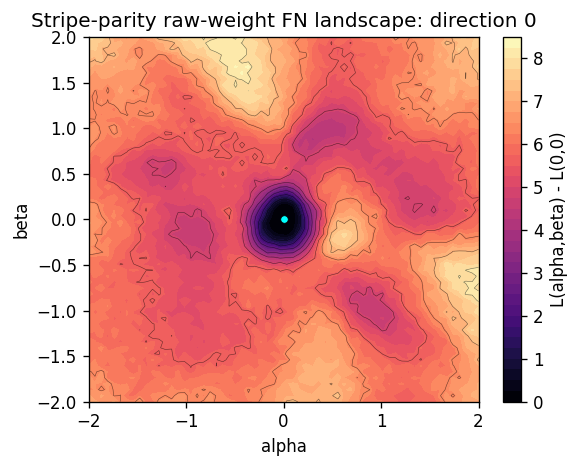

In [6]:
def filterwise_normalized_flat_direction(
    model: nn.Module,
    *,
    generator: torch.Generator,
) -> torch.Tensor:
    parts: list[torch.Tensor] = []
    for name, param in named_trainable_parameters(model):
        value = param.detach()
        if value.ndim >= 2 and name.endswith('weight'):
            noise = torch.randn(value.shape, generator=generator, dtype=value.dtype, device='cpu').to(value.device)
            flat_value = value.reshape(value.shape[0], -1)
            flat_noise = noise.reshape(noise.shape[0], -1)
            value_norm = flat_value.norm(dim=1, keepdim=True).clamp_min(1e-12)
            noise_norm = flat_noise.norm(dim=1, keepdim=True).clamp_min(1e-12)
            direction = (flat_noise / noise_norm * value_norm).reshape_as(value)
        else:
            direction = torch.zeros_like(value)
        parts.append(direction.reshape(-1))
    return torch.cat(parts).detach().clone()


def make_raw_direction_pairs(
    model: nn.Module,
    num_pairs: int,
    *,
    seed: int,
) -> list[tuple[torch.Tensor, torch.Tensor]]:
    generator = torch.Generator(device='cpu')
    generator.manual_seed(int(seed))
    return [
        (
            filterwise_normalized_flat_direction(model, generator=generator),
            filterwise_normalized_flat_direction(model, generator=generator),
        )
        for _ in range(int(num_pairs))
    ]


@dataclass
class LandscapeResult:
    kind: str
    direction_idx: int
    alphas: np.ndarray
    betas: np.ndarray
    losses: np.ndarray
    base_loss: float


def evaluate_landscape(
    *,
    kind: str,
    direction_pairs: list[Any],
    base_loss: float,
    eval_fn,
    grid_points: int,
    rho_max: float,
) -> list[LandscapeResult]:
    alphas = np.linspace(-float(rho_max), float(rho_max), int(grid_points))
    betas = np.linspace(-float(rho_max), float(rho_max), int(grid_points))
    results = []
    for direction_idx, pair in enumerate(direction_pairs):
        losses = np.full((len(alphas), len(betas)), np.nan, dtype=np.float64)
        t0 = time.time()
        for i, alpha in enumerate(alphas):
            for j, beta in enumerate(betas):
                losses[i, j] = float(eval_fn(pair, float(alpha), float(beta)))
        result = LandscapeResult(
            kind=kind,
            direction_idx=direction_idx,
            alphas=alphas,
            betas=betas,
            losses=losses,
            base_loss=float(base_loss),
        )
        results.append(result)
        print(
            f'{kind} direction={direction_idx} done in {time.time() - t0:.1f}s '
            f'min_delta={np.nanmin(losses - base_loss):.4f} max_delta={np.nanmax(losses - base_loss):.4f}'
        )
    return results


def compute_landscape_metrics(
    results: list[LandscapeResult],
    rho_values: Iterable[float],
    tau_values: Iterable[float],
) -> pd.DataFrame:
    rows = []
    for result in results:
        alpha_grid, beta_grid = np.meshgrid(result.alphas, result.betas, indexing='ij')
        delta = result.losses - result.base_loss
        step_alpha = float(abs(result.alphas[1] - result.alphas[0])) if len(result.alphas) > 1 else 1.0
        step_beta = float(abs(result.betas[1] - result.betas[0])) if len(result.betas) > 1 else 1.0
        cell_area = step_alpha * step_beta
        radius2 = alpha_grid * alpha_grid + beta_grid * beta_grid
        for rho in rho_values:
            disk = radius2 <= float(rho) ** 2 + 1e-12
            disk_delta = delta[disk]
            row = {
                'kind': result.kind,
                'direction_idx': result.direction_idx,
                'rho': float(rho),
                'S_rho': float(np.nanmax(disk_delta)),
                'M_rho': float(np.nanmean(disk_delta)),
                'disk_grid_points': int(disk.sum()),
            }
            for tau in tau_values:
                good = disk & (result.losses <= result.base_loss + float(tau))
                row[f'A_tau={tau:g}_rho'] = float(good.sum() * cell_area)
                row[f'A_frac_tau={tau:g}_rho'] = float(good.sum() / max(1, disk.sum()))
            rows.append(row)
    return pd.DataFrame(rows)


def plot_landscape(
    result: LandscapeResult,
    title: str | None = None,
    save_path: Path | None = None,
    *,
    markers: list[dict[str, Any]] | None = None,
) -> None:
    alpha_grid, beta_grid = np.meshgrid(result.alphas, result.betas, indexing='ij')
    delta = result.losses - result.base_loss
    marker_items = markers or []
    plt.figure(figsize=(5, 4))
    contour = plt.contourf(alpha_grid, beta_grid, delta, levels=40, cmap='magma')
    plt.colorbar(contour, label='L(alpha,beta) - L(0,0)')
    plt.contour(alpha_grid, beta_grid, delta, colors='black', linewidths=0.35, levels=12, alpha=0.55)
    plt.scatter([0], [0], c='cyan', s=20, edgecolors='black', linewidths=0.4, label='primary latent solution')
    for marker in marker_items:
        alpha = float(marker['alpha'])
        beta = float(marker['beta'])
        label = str(marker.get('label', marker.get('task_name', 'transfer')))
        color = marker.get('color', 'lime')
        plt.scatter(
            [alpha],
            [beta],
            c=color,
            s=170,
            marker='*',
            edgecolors='black',
            linewidths=0.7,
            label=label,
            zorder=5,
            clip_on=False,
        )
        plt.text(alpha, beta, f' {label}', color='white', fontsize=8, weight='bold', va='center', clip_on=False)
    if marker_items:
        x_values = list(result.alphas) + [float(marker['alpha']) for marker in marker_items]
        y_values = list(result.betas) + [float(marker['beta']) for marker in marker_items]
        x_min, x_max = min(x_values), max(x_values)
        y_min, y_max = min(y_values), max(y_values)
        x_pad = max(1e-6, 0.05 * (x_max - x_min))
        y_pad = max(1e-6, 0.05 * (y_max - y_min))
        plt.xlim(x_min - x_pad, x_max + x_pad)
        plt.ylim(y_min - y_pad, y_max + y_pad)
        plt.legend(loc='best', fontsize=8, framealpha=0.85)
    plt.xlabel('alpha')
    plt.ylabel('beta')
    plt.title(title or f'{result.kind} direction {result.direction_idx}')
    plt.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()


def plot_landscape_3d(
    result: LandscapeResult,
    title: str | None = None,
    *,
    z_mode: str = 'delta',
    save_html_path: Path | None = None,
    markers: list[dict[str, Any]] | None = None,
):
    """Interactive Plotly 3D surface for rotating the loss landscape in a notebook."""
    if go is None:
        print('Skipping interactive 3D plot: plotly is not installed. Install it with: pip install plotly')
        return None
    if z_mode not in {'delta', 'loss'}:
        raise ValueError(f'z_mode must be delta or loss, got {z_mode!r}')
    marker_items = markers or []
    alpha_grid, beta_grid = np.meshgrid(result.alphas, result.betas, indexing='ij')
    z = result.losses - result.base_loss if z_mode == 'delta' else result.losses
    z_label = 'L(alpha,beta) - L(0,0)' if z_mode == 'delta' else 'L(alpha,beta)'
    base_z = 0.0 if z_mode == 'delta' else float(result.base_loss)
    traces = [
        go.Surface(
            x=alpha_grid,
            y=beta_grid,
            z=z,
            surfacecolor=z,
            colorscale='Magma',
            colorbar={'title': z_label},
            contours={
                'z': {
                    'show': True,
                    'usecolormap': True,
                    'highlightcolor': 'white',
                    'project_z': True,
                }
            },
            hovertemplate='alpha=%{x:.3f}<br>beta=%{y:.3f}<br>' + z_label + '=%{z:.5f}<extra></extra>',
        ),
        go.Scatter3d(
            x=[0.0],
            y=[0.0],
            z=[base_z],
            mode='markers',
            marker={'size': 5, 'color': 'cyan', 'line': {'color': 'black', 'width': 2}},
            name='primary latent solution',
        ),
    ]
    if marker_items:
        marker_z_values = []
        marker_text = []
        marker_colors = []
        for marker in marker_items:
            if z_mode == 'delta':
                marker_z_values.append(float(marker.get('delta', float('nan'))))
            else:
                marker_z_values.append(float(marker.get('loss', float('nan'))))
            marker_text.append(str(marker.get('label', marker.get('task_name', 'transfer'))))
            marker_colors.append(marker.get('color', 'lime'))
        traces.append(
            go.Scatter3d(
                x=[float(marker['alpha']) for marker in marker_items],
                y=[float(marker['beta']) for marker in marker_items],
                z=marker_z_values,
                mode='markers+text',
                text=marker_text,
                textposition='top center',
                marker={'size': 8, 'color': marker_colors, 'symbol': 'diamond', 'line': {'color': 'black', 'width': 2}},
                name='transfer optima projected',
                hovertemplate='task=%{text}<br>alpha=%{x:.3f}<br>beta=%{y:.3f}<br>' + z_label + '=%{z:.5f}<extra></extra>',
            )
        )
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title or f'{result.kind} direction {result.direction_idx}',
        scene={
            'xaxis_title': 'alpha',
            'yaxis_title': 'beta',
            'zaxis_title': z_label,
            'camera': {'eye': {'x': 1.55, 'y': -1.55, 'z': 1.1}},
        },
        width=850,
        height=650,
        margin={'l': 0, 'r': 0, 'b': 0, 't': 45},
    )
    if save_html_path is not None:
        save_html_path.parent.mkdir(parents=True, exist_ok=True)
        fig.write_html(save_html_path, include_plotlyjs='cdn')
    fig.show()
    return fig


def plot_metric_boxplots(metrics: pd.DataFrame, metric: str, save_path: Path | None = None) -> None:
    plt.figure(figsize=(6, 4))
    labels = []
    values = []
    for (kind, rho), group in metrics.groupby(['kind', 'rho']):
        labels.append(f'{kind}\nrho={rho:g}')
        values.append(group[metric].to_numpy())
    plt.boxplot(values, labels=labels, showmeans=True)
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()


raw_model = TinyStripeParityViT(cfg).to(device)
raw_model.load_state_dict(base_state, strict=True)
raw_base_flat = get_flat_params(raw_model)
landscape_split = str(cfg.landscape_split).strip().lower()
if landscape_split not in {'train', 'val'}:
    raise ValueError(f'cfg.landscape_split must be train or val, got {cfg.landscape_split!r}')
landscape_loader = train_loader if landscape_split == 'train' else val_loader
landscape_max_batches = None if int(cfg.landscape_max_batches) <= 0 else int(cfg.landscape_max_batches)
print('landscape_split', landscape_split)
raw_base_loss, raw_base_acc = evaluate_loss(raw_model, landscape_loader, max_batches=landscape_max_batches)
print(f'raw_base_{landscape_split}_loss', raw_base_loss, f'raw_base_{landscape_split}_acc', raw_base_acc)
raw_direction_pairs = make_raw_direction_pairs(raw_model, cfg.num_directions, seed=cfg.seed + 1000)


def raw_eval_fn(pair, alpha: float, beta: float) -> float:
    d1, d2 = pair
    flat = raw_base_flat + float(alpha) * d1 + float(beta) * d2
    loss, _acc = loss_at_flat_params(raw_model, flat, landscape_loader, max_batches=landscape_max_batches, restore=False)
    return loss


raw_results = evaluate_landscape(
    kind='raw_fn',
    direction_pairs=raw_direction_pairs,
    base_loss=raw_base_loss,
    eval_fn=raw_eval_fn,
    grid_points=cfg.grid_points,
    rho_max=cfg.rho_max,
)
set_flat_params_(raw_model, raw_base_flat)
raw_metrics = compute_landscape_metrics(raw_results, cfg.rho_values, cfg.tau_values)
display(raw_metrics)
plot_landscape(
    raw_results[0],
    'Stripe-parity raw-weight FN landscape: direction 0',
    save_path=artifact_dir / 'raw_fn_direction_0_2d.png',
)
plot_landscape_3d(
    raw_results[0],
    'Interactive 3D raw-weight FN landscape: direction 0',
    save_html_path=artifact_dir / 'raw_fn_direction_0_3d.html',
)


## BigVAE latent-induced landscape

This section is optional. It loads a frozen BigVAE decoder and builds a latent parameterization of the tiny ViT's 2D linear weights. The initial latent point is produced by the BigVAE encoder from trained weights and real layer input activations `X`. Optional decoded-weight MSE refinement is available via `latent_base_mode='encoder_fit'` or `latent_base_mode='fit'`. Then the latent slots themselves are optimized on the stripe-parity cross-entropy task loss while the BigVAE decoder stays frozen.

Then random latent directions are sampled with tile-wise latent norm matching, the latent slots are perturbed by `(alpha, beta)`, decoded into raw tiny-ViT weights, and the same stripe-parity validation loss is evaluated.

The decoder sees fixed stage-like tiles: `d_in = patch_size_bigvae * big_vae_tile_T_patches`, `d_out = big_vae_tile_d_out`. Small matrices are packed by patch rows into these tiles to avoid paying one latent for mostly empty padding.


In [7]:
@dataclass
class MatrixSpec:
    original_shape: tuple[int, ...]
    matrix_shape: tuple[int, int]
    transposed: bool


@dataclass
class TileSegment:
    name: str
    tile_row_start: int
    row_start: int
    row_len: int
    col_start: int
    col_len: int


@dataclass
class DecodeTile:
    key: str
    name: str
    segments: list[TileSegment]


def tensor_to_matrix(tensor: torch.Tensor, spec: MatrixSpec) -> torch.Tensor:
    matrix = tensor.reshape(int(spec.original_shape[0]), -1)
    if spec.transposed:
        matrix = matrix.transpose(0, 1)
    return matrix.contiguous()


def matrix_to_tensor(matrix: torch.Tensor, spec: MatrixSpec) -> torch.Tensor:
    restored = matrix.transpose(0, 1) if spec.transposed else matrix
    return restored.contiguous().reshape(spec.original_shape)


def load_frozen_big_vae(checkpoint_path: str, device: torch.device):
    if not checkpoint_path:
        return None
    if BigWeightVAE is None:
        raise RuntimeError('BigVAE imports are unavailable in this kernel')
    path = Path(checkpoint_path).expanduser()
    payload = torch.load(path, map_location='cpu', weights_only=False)
    cfg_payload = OmegaConf.create(payload['config'])
    model_cfg = _build_model_cfg(cfg_payload)
    model = build_weight_quantile_vae(model_cfg)
    state = _normalize_model_state_dict_keys(payload.get('model_state', payload.get('state_dict')))

    target_state = model.state_dict()
    missing = sorted(key for key in target_state.keys() if key not in state)
    unexpected = sorted(key for key in state.keys() if key not in target_state)
    posterior_prefixes = ('to_mu.', 'to_logvar.')
    allowed_missing = sorted(key for key in missing if any(key.startswith(prefix) for prefix in posterior_prefixes))

    if missing or unexpected:
        can_migrate_ae_checkpoint = bool(getattr(model.cfg.big_vae, 'use_latent_sampling', False)) and allowed_missing == missing and not unexpected
        if can_migrate_ae_checkpoint:
            incompatible = model.load_state_dict(state, strict=False)
            missing_after = sorted(getattr(incompatible, 'missing_keys', []))
            unexpected_after = sorted(getattr(incompatible, 'unexpected_keys', []))
            disallowed_missing = [key for key in missing_after if not any(key.startswith(prefix) for prefix in posterior_prefixes)]
            if disallowed_missing or unexpected_after:
                raise RuntimeError(
                    'BigVAE AE->VAE migration failed: '
                    f'missing={missing_after[:8]} unexpected={unexpected_after[:8]}'
                )
            print('loaded AE checkpoint into VAE-style BigVAE; posterior heads kept from current init')
        else:
            raise RuntimeError(f'BigVAE state mismatch: missing={missing[:8]} unexpected={unexpected[:8]}')
    else:
        model.load_state_dict(state, strict=True)

    model.to(device).eval()
    for param in model.parameters():
        param.requires_grad_(False)
    return model


@torch.no_grad()
def collect_calibration_images(loader: DataLoader, num_batches: int) -> torch.Tensor:
    batches: list[torch.Tensor] = []
    for batch_idx, (images, _labels) in enumerate(loader):
        if int(num_batches) > 0 and batch_idx >= int(num_batches):
            break
        batches.append(images.detach().clone())
    if not batches:
        raise RuntimeError('No calibration images were collected')
    return torch.cat(batches, dim=0)


def notebook_layer_type(layer_name: str) -> str:
    name = str(layer_name).strip().lower()
    if name == 'patch_embed.weight':
        return 'embedding'
    if name.endswith('.attn.in_proj_weight'):
        return 'attn_other'
    if name.endswith('.attn.out_proj.weight'):
        return 'attn_output'
    if name.endswith('.mlp.0.weight'):
        return 'ffn_up'
    if name.endswith('.mlp.2.weight'):
        return 'ffn_down'
    if name == 'head.weight':
        return 'head'
    if infer_layer_type is None:
        return 'other_linear'
    return infer_layer_type(layer_name)


def notebook_layer_depth(layer_name: str) -> int | None:
    if infer_layer_depth is None:
        return None
    return infer_layer_depth(layer_name)


def build_notebook_metadata_condition(
    big_vae: nn.Module,
    layer_names: list[str],
    *,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor | None:
    if build_layer_metadata_condition_vector is None or latent_diffusion_layer_type_to_id is None:
        return None
    use_type = bool(getattr(big_vae, 'use_distribution_encoder', False))
    # metadata shape is controlled by the prior config; if notebook-only BigVAE has no prior, return None.
    return None


class BigVAELatentAdapter(nn.Module):
    def __init__(
        self,
        big_vae: nn.Module,
        base_state: dict[str, torch.Tensor],
        cfg: Config,
        *,
        latent_space: str = 'encoder_slots',
        latent_diffusion_prior: nn.Module | None = None,
    ) -> None:
        super().__init__()
        self.big_vae = big_vae
        self.patch_size = int(big_vae.cfg.patch_size)
        self.tile_T = int(cfg.big_vae_tile_T_patches)
        self.tile_d_in = self.patch_size * self.tile_T
        self.tile_d_out = int(cfg.big_vae_tile_d_out)
        self.use_dist = bool(getattr(big_vae, 'use_distribution_encoder', False))
        self.d_dist = int(big_vae.cfg.distribution.d_dist)
        self.latent_space = str(latent_space).strip().lower()
        if self.latent_space not in {'encoder_slots', 'decoder_z'}:
            raise ValueError(f'latent_space must be encoder_slots or decoder_z, got {latent_space!r}')
        self.latent_diffusion_prior = latent_diffusion_prior
        self.specs: dict[str, MatrixSpec] = {}
        self.tiles: list[DecodeTile] = []
        self.tiles_by_name: dict[str, list[DecodeTile]] = {}
        self.direct_state = {k: v.detach().clone().to(device) for k, v in base_state.items()}
        self.latents = nn.ParameterDict()
        self.tile_cond_patch: dict[str, torch.Tensor] = {}

        base_latent = big_vae.latent_base.detach().clone().to(device)
        if self.latent_space == 'decoder_z':
            base_z = big_vae.latent_norm(base_latent.reshape(1, -1))
            base_latent = big_vae._sample_latent_posterior(base_z)[0].view_as(base_latent).squeeze(0).detach().clone()

        for name, value in base_state.items():
            if not (value.ndim == 2 and name.endswith('weight')):
                continue
            spec = MatrixSpec(tuple(value.shape), (int(value.shape[1]), int(value.shape[0])), True)
            self.specs[name] = spec
            rows, cols = spec.matrix_shape
            pending: list[TileSegment] = []
            current_rows = 0

            def flush() -> None:
                nonlocal pending, current_rows
                if not pending:
                    return
                key = f't{len(self.tiles):05d}'
                tile = DecodeTile(key=key, name=name, segments=list(pending))
                self.tiles.append(tile)
                self.tiles_by_name.setdefault(name, []).append(tile)
                if cfg.big_vae_latent_init == 'base':
                    latent = base_latent.clone()
                else:
                    latent = torch.randn_like(base_latent) * 0.02
                self.latents[key] = nn.Parameter(latent)
                pending = []
                current_rows = 0

            for col_start in range(0, cols, self.tile_d_out):
                col_len = min(self.tile_d_out, cols - col_start)
                for row_start in range(0, rows, self.patch_size):
                    row_len = min(self.patch_size, rows - row_start)
                    if current_rows > 0 and current_rows + row_len > self.tile_d_in:
                        flush()
                    pending.append(TileSegment(name, current_rows, row_start, row_len, col_start, col_len))
                    current_rows += row_len
                    if current_rows >= self.tile_d_in:
                        flush()
            flush()

    def decoded_tensor_execution_order(self) -> list[str]:
        names = list(self.tiles_by_name.keys())
        def sort_key(name: str):
            raw = str(name)
            if raw == 'patch_embed.weight':
                return (0, 0, raw)
            if raw.startswith('blocks.'):
                parts = raw.split('.')
                block_idx = int(parts[1])
                if raw.endswith('.attn.in_proj_weight'):
                    return (1 + block_idx, 0, raw)
                if raw.endswith('.attn.out_proj.weight'):
                    return (1 + block_idx, 1, raw)
                if raw.endswith('.mlp.0.weight'):
                    return (1 + block_idx, 2, raw)
                if raw.endswith('.mlp.2.weight'):
                    return (1 + block_idx, 3, raw)
                return (1 + block_idx, 100, raw)
            if raw == 'head.weight':
                return (10_000, 0, raw)
            return (20_000, 0, raw)
        return sorted(names, key=sort_key)

    def latent_numel(self) -> int:
        return sum(param.numel() for param in self.latents.values())

    def decoded_numel(self) -> int:
        return sum(int(np.prod(self.direct_state[name].shape)) for name in self.specs)

    def _tile_masks(self, tile_keys: list[str]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        batch = int(len(tile_keys))
        patch_mask = torch.zeros(batch, self.tile_T, device=device, dtype=torch.bool)
        d_in_mask = torch.zeros(batch, self.tile_d_in, device=device, dtype=torch.bool)
        d_out_mask = torch.zeros(batch, self.tile_d_out, device=device, dtype=torch.bool)
        key_to_tile = {tile.key: tile for tile in self.tiles}
        for idx, key in enumerate(tile_keys):
            tile = key_to_tile[key]
            used_rows = 0
            used_cols = 0
            for seg in tile.segments:
                row_end = seg.tile_row_start + seg.row_len
                d_in_mask[idx, seg.tile_row_start:row_end] = True
                used_rows = max(used_rows, row_end)
                used_cols = max(used_cols, seg.col_len)
            patch_mask[idx, :math.ceil(used_rows / self.patch_size)] = True
            d_out_mask[idx, :used_cols] = True
        return patch_mask, d_in_mask, d_out_mask

    def decode_matrices(self, latent_override: dict[str, torch.Tensor] | None = None) -> dict[str, torch.Tensor]:
        result = {name: torch.zeros(spec.matrix_shape, device=device) for name, spec in self.specs.items()}
        if not self.tiles:
            return result
        keys = [tile.key for tile in self.tiles]
        latents = torch.stack([(latent_override or self.latents)[key] for key in keys], dim=0)
        patch_mask, d_in_mask, d_out_mask = self._tile_masks(keys)
        if self.use_dist:
            if all(key in self.tile_cond_patch for key in keys):
                dist_patch = torch.stack([self.tile_cond_patch[key].to(device=device, dtype=latents.dtype) for key in keys], dim=0)
            else:
                dist_patch = torch.zeros(len(keys), self.tile_T, self.d_dist, device=device, dtype=latents.dtype)
        else:
            dist_patch = None
        if self.latent_space == 'decoder_z':
            decoded = self.big_vae._decode_from_decoder_latent(
                latents,
                dist_patch_by_patch=dist_patch,
                patch_mask=patch_mask,
                d_in_mask=d_in_mask,
                d_out_mask=d_out_mask,
                d_in=self.tile_d_in,
                d_out=self.tile_d_out,
                d_in_pad=self.tile_d_in,
                T=self.tile_T,
            )[0]
        else:
            decoded = self.big_vae._decode_from_latent_slots(
                latents,
                dist_patch_by_patch=dist_patch,
                patch_mask=patch_mask,
                d_in_mask=d_in_mask,
                d_out_mask=d_out_mask,
                d_in=self.tile_d_in,
                d_out=self.tile_d_out,
                d_in_pad=self.tile_d_in,
                T=self.tile_T,
            )[0]
        for idx, tile in enumerate(self.tiles):
            for seg in tile.segments:
                row_end = seg.tile_row_start + seg.row_len
                result[seg.name][seg.row_start:seg.row_start + seg.row_len, seg.col_start:seg.col_start + seg.col_len] = decoded[
                    idx,
                    seg.tile_row_start:row_end,
                    :seg.col_len,
                ]
        return result

    def tile_weight_and_context(
        self,
        tile: DecodeTile,
        base_state: dict[str, torch.Tensor],
        contexts: dict[str, torch.Tensor],
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        first_context = contexts[tile.segments[0].name]
        n = int(first_context.shape[0])
        W_tile = torch.zeros(self.tile_d_in, self.tile_d_out, device=device, dtype=torch.float32)
        X_tile = torch.zeros(n, self.tile_d_in, device=device, dtype=torch.float32)
        d_in_mask = torch.zeros(self.tile_d_in, device=device, dtype=torch.bool)
        d_out_mask = torch.zeros(self.tile_d_out, device=device, dtype=torch.bool)
        for seg in tile.segments:
            if seg.name not in contexts:
                raise KeyError(f'missing encoder context for {seg.name}')
            X_src = contexts[seg.name]
            if int(X_src.shape[0]) != n:
                X_src = X_src[:n]
            matrix = tensor_to_matrix(base_state[seg.name].to(device), self.specs[seg.name])
            row_end = seg.tile_row_start + seg.row_len
            W_tile[seg.tile_row_start:row_end, :seg.col_len] = matrix[
                seg.row_start:seg.row_start + seg.row_len,
                seg.col_start:seg.col_start + seg.col_len,
            ]
            X_tile[:, seg.tile_row_start:row_end] = X_src[:, seg.row_start:seg.row_start + seg.row_len]
            d_in_mask[seg.tile_row_start:row_end] = True
            d_out_mask[:seg.col_len] = True
        return W_tile, X_tile, d_in_mask, d_out_mask

    @torch.no_grad()
    def initialize_latents_from_encoder(self, base_state: dict[str, torch.Tensor], contexts: dict[str, torch.Tensor]) -> None:
        encoded: dict[str, torch.Tensor] = {}
        for idx, tile in enumerate(self.tiles):
            W_tile, X_tile, d_in_mask, d_out_mask = self.tile_weight_and_context(tile, base_state, contexts)
            W_b = W_tile.unsqueeze(0)
            X_b = X_tile.unsqueeze(0)
            d_in_mask_b = d_in_mask.unsqueeze(0)
            d_out_mask_b = d_out_mask.unsqueeze(0)
            T, d_in_pad, patch_mask, _structural_patch_mask, dist_var_by_patch, dist_patch_by_patch, dist_var_pooled = self.big_vae._encode_distribution_context(
                X_b,
                x_mask=None,
                d_in_mask=d_in_mask_b,
            )
            latents = self.big_vae._encode_latent_slots(
                W_b,
                T=T,
                d_in_pad=d_in_pad,
                patch_mask=patch_mask,
                d_out_mask=d_out_mask_b,
                dist_var_by_patch=dist_var_by_patch,
                dist_patch_by_patch=dist_patch_by_patch,
                dist_var_pooled=dist_var_pooled,
                return_debug_info=False,
            )
            if self.latent_space == 'decoder_z':
                base_z = self.big_vae.latent_norm(latents.reshape(1, -1))
                value = self.big_vae._sample_latent_posterior(base_z)[0].view_as(latents).squeeze(0).detach().clone()
            else:
                value = latents.squeeze(0).detach().clone()
            encoded[tile.key] = value
            self.tile_cond_patch[tile.key] = dist_patch_by_patch.squeeze(0).detach().clone()
            if idx == 0 or (idx + 1) % 50 == 0 or idx + 1 == len(self.tiles):
                print(f'encoded latent tile {idx + 1}/{len(self.tiles)}', flush=True)
        for key, value in encoded.items():
            if tuple(self.latents[key].shape) != tuple(value.shape):
                raise RuntimeError(f'encoder latent shape mismatch for {key}: param={tuple(self.latents[key].shape)} encoded={tuple(value.shape)}')
            self.latents[key].copy_(value)

    @torch.no_grad()
    def initialize_from_diffusion_prior_autoregressive(
        self,
        model: TinyStripeParityViT,
        *,
        calibration_images: torch.Tensor,
        prior_steps: int,
        prior_sampler: str,
        prior_eta: float,
    ) -> None:
        if self.latent_space != 'decoder_z':
            raise RuntimeError('autoregressive diffusion prior init requires latent_space=decoder_z')
        if self.latent_diffusion_prior is None:
            raise RuntimeError('latent_diffusion_prior is required for autoregressive initialization')
        if calibration_images.ndim != 4:
            raise ValueError(f'calibration_images must be [B,C,H,W], got {tuple(calibration_images.shape)}')

        scaffold_state = {k: v.detach().clone().to(device) for k, v in model.state_dict().items()}
        working_model = TinyStripeParityViT(model.cfg).to(device)
        working_model.load_state_dict(scaffold_state, strict=True)
        images = calibration_images.to(device=device, dtype=torch.float32, non_blocking=False)

        for tensor_name in self.decoded_tensor_execution_order():
            X_full = working_model.collect_parameter_input_matrix(tensor_name, images).to(device=device, dtype=torch.float32)
            tile_batch = self.tiles_by_name.get(tensor_name, [])
            if not tile_batch:
                continue

            X = torch.zeros(len(tile_batch), int(X_full.shape[0]), int(self.tile_d_in), device=device, dtype=torch.float32)
            x_mask = torch.ones(len(tile_batch), int(X_full.shape[0]), device=device, dtype=torch.bool)
            d_in_mask = torch.zeros(len(tile_batch), int(self.tile_d_in), device=device, dtype=torch.bool)
            layer_type_ids: list[int] = []
            layer_depths: list[int | None] = []
            for item_idx, tile in enumerate(tile_batch):
                for segment in tile.segments:
                    tile_row_start = int(segment.tile_row_start)
                    tile_row_end = tile_row_start + int(segment.row_len)
                    row_start = int(segment.row_start)
                    row_end = row_start + int(segment.row_len)
                    X[item_idx, :, tile_row_start:tile_row_end] = X_full[:, row_start:row_end]
                    d_in_mask[item_idx, tile_row_start:tile_row_end] = True
                layer_type_ids.append(latent_diffusion_layer_type_to_id(notebook_layer_type(tile.name)))
                layer_depths.append(notebook_layer_depth(tile.name))

            (
                T,
                _d_in_pad,
                patch_mask,
                _structural_patch_mask,
                _dist_var_by_patch,
                dist_patch_by_patch,
                dist_var_pooled,
            ) = self.big_vae._encode_distribution_context(
                X,
                x_mask=x_mask,
                d_in_mask=d_in_mask,
            )
            cond_global = build_cond_global_from_dist_var_pooled(
                dist_var_pooled=dist_var_pooled,
                patch_mask=patch_mask,
            )
            metadata_cond = None
            if build_layer_metadata_condition_vector is not None:
                metadata_cond = build_layer_metadata_condition_vector(
                    device=device,
                    dtype=torch.float32,
                    use_layer_type_conditioning=bool(getattr(self.latent_diffusion_prior.cfg, 'use_layer_type_conditioning', False)),
                    use_layer_depth_conditioning=bool(getattr(self.latent_diffusion_prior.cfg, 'use_layer_depth_conditioning', False)),
                    depth_fourier_dim=int(getattr(self.latent_diffusion_prior.cfg, 'layer_depth_fourier_dim', 16)),
                    depth_scale=float(getattr(self.latent_diffusion_prior.cfg, 'layer_depth_scale', 64.0)),
                    layer_type_ids=layer_type_ids,
                    layer_depths=layer_depths,
                )
            if metadata_cond is not None:
                if cond_global is None:
                    cond_global = metadata_cond
                else:
                    cond_global = torch.cat([cond_global.to(device=device, dtype=torch.float32), metadata_cond], dim=-1)

            sampled = self.latent_diffusion_prior.sample_latents(
                cond_patch=dist_patch_by_patch,
                cond_global=cond_global,
                patch_mask=patch_mask,
                num_steps=int(prior_steps),
                sampler_type=str(prior_sampler),
                eta=float(prior_eta),
            )
            sampled = sampled.view(len(tile_batch), *next(iter(self.latents.values())).shape)
            for item_idx, tile in enumerate(tile_batch):
                self.latents[tile.key].copy_(sampled[item_idx].detach().to(device=self.latents[tile.key].device, dtype=self.latents[tile.key].dtype))
                self.tile_cond_patch[tile.key] = dist_patch_by_patch[item_idx].detach().clone()

            state = self.materialize_state()
            working_model.load_state_dict(state, strict=False)
            print(f'diffusion prior initialized {tensor_name}', flush=True)

    def materialize_state(self, latent_override: dict[str, torch.Tensor] | None = None) -> dict[str, torch.Tensor]:
        state = {k: v.detach().clone() for k, v in self.direct_state.items()}
        matrices = self.decode_matrices(latent_override)
        for name, matrix in matrices.items():
            state[name] = matrix_to_tensor(matrix, self.specs[name])
        return state


def fit_latents_to_base(adapter: BigVAELatentAdapter, base_state: dict[str, torch.Tensor], steps: int, lr: float) -> None:
    opt = torch.optim.AdamW(adapter.latents.parameters(), lr=lr, weight_decay=0.0)
    targets = {name: tensor_to_matrix(base_state[name].to(device), spec) for name, spec in adapter.specs.items()}
    total = sum(target.numel() for target in targets.values())
    for step in range(1, int(steps) + 1):
        opt.zero_grad(set_to_none=True)
        decoded = adapter.decode_matrices()
        loss = sum(F.mse_loss(decoded[name], target, reduction='sum') for name, target in targets.items()) / max(1, total)
        loss.backward()
        opt.step()
        if step == 1 or step % max(1, int(steps) // 5) == 0 or step == int(steps):
            print(f'latent fit step={step}/{steps} mse={float(loss.detach().cpu()):.6e}')


def make_latent_direction(adapter: BigVAELatentAdapter, generator: torch.Generator) -> dict[str, torch.Tensor]:
    direction = {}
    for key, latent in adapter.latents.items():
        noise = torch.randn(latent.shape, generator=generator, dtype=latent.dtype, device='cpu').to(latent.device)
        direction[key] = noise / noise.norm().clamp_min(1e-12) * latent.detach().norm().clamp_min(1e-12)
    return direction


def make_latent_direction_pairs(adapter: BigVAELatentAdapter, num_pairs: int, seed: int):
    generator = torch.Generator(device='cpu')
    generator.manual_seed(int(seed))
    return [(make_latent_direction(adapter, generator), make_latent_direction(adapter, generator)) for _ in range(int(num_pairs))]


def call_tiny_vit_with_state(model: TinyStripeParityViT, state: dict[str, torch.Tensor], images: torch.Tensor) -> torch.Tensor:
    return functional_call(model, state, (images,))


@torch.no_grad()
def evaluate_latent_adapter(
    adapter: BigVAELatentAdapter,
    model_template: TinyStripeParityViT,
    loader: DataLoader,
    *,
    max_batches: int | None = None,
) -> tuple[float, float]:
    model_template.eval()
    state = adapter.materialize_state()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = call_tiny_vit_with_state(model_template, state, images)
        loss = F.cross_entropy(logits, labels, reduction='sum')
        total_loss += float(loss.detach().cpu())
        total_correct += int((logits.argmax(dim=-1) == labels).sum().detach().cpu())
        total += int(labels.numel())
    return total_loss / max(1, total), total_correct / max(1, total)


def train_latents_on_task(
    adapter: BigVAELatentAdapter,
    model_template: TinyStripeParityViT,
    train_loader: DataLoader,
    val_loader: DataLoader,
    cfg: Config,
    *,
    max_eval_batches: int | None = None,
) -> None:
    steps = int(cfg.latent_task_train_steps)
    if steps <= 0:
        print('latent task training disabled: cfg.latent_task_train_steps <= 0')
        return
    model_template.eval()
    for param in model_template.parameters():
        param.requires_grad_(False)
    opt = torch.optim.AdamW(
        adapter.latents.parameters(),
        lr=float(cfg.latent_task_lr),
        weight_decay=float(cfg.latent_task_weight_decay),
    )
    batches = itertools.cycle(train_loader)
    log_every = max(1, int(cfg.latent_task_log_every))
    for step in range(1, steps + 1):
        images, labels = next(batches)
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        state = adapter.materialize_state()
        logits = call_tiny_vit_with_state(model_template, state, images)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        if float(cfg.latent_task_grad_clip_norm) > 0:
            torch.nn.utils.clip_grad_norm_(adapter.latents.parameters(), float(cfg.latent_task_grad_clip_norm))
        opt.step()
        if step == 1 or step % log_every == 0 or step == steps:
            batch_acc = float((logits.argmax(dim=-1) == labels).float().mean().detach().cpu())
            val_loss, val_acc = evaluate_latent_adapter(adapter, model_template, val_loader, max_batches=max_eval_batches)
            print(
                f'latent task step={step}/{steps} loss={float(loss.detach().cpu()):.4f} '
                f'batch_acc={batch_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
            )



def clone_latent_state(adapter: BigVAELatentAdapter) -> dict[str, torch.Tensor]:
    return {key: value.detach().clone() for key, value in adapter.latents.items()}


@torch.no_grad()
def load_latent_state_(adapter: BigVAELatentAdapter, latent_state: dict[str, torch.Tensor]) -> None:
    missing = sorted(set(adapter.latents.keys()) - set(latent_state.keys()))
    extra = sorted(set(latent_state.keys()) - set(adapter.latents.keys()))
    if missing or extra:
        raise RuntimeError(f'latent state key mismatch: missing={missing[:5]} extra={extra[:5]}')
    for key, value in latent_state.items():
        if tuple(adapter.latents[key].shape) != tuple(value.shape):
            raise RuntimeError(f'latent state shape mismatch for {key}: param={tuple(adapter.latents[key].shape)} value={tuple(value.shape)}')
        adapter.latents[key].copy_(value.to(device=adapter.latents[key].device, dtype=adapter.latents[key].dtype))


def latent_dict_dot(lhs: dict[str, torch.Tensor], rhs: dict[str, torch.Tensor]) -> torch.Tensor:
    total = None
    for key in lhs.keys():
        value = (lhs[key].reshape(-1) * rhs[key].reshape(-1)).sum()
        total = value if total is None else total + value
    if total is None:
        return torch.tensor(0.0, device=device)
    return total


def latent_dict_delta(
    solution: dict[str, torch.Tensor],
    center: dict[str, torch.Tensor],
) -> dict[str, torch.Tensor]:
    return {key: solution[key] - center[key] for key in center.keys()}


def project_latent_solution_to_pair(
    *,
    center: dict[str, torch.Tensor],
    solution: dict[str, torch.Tensor],
    pair: tuple[dict[str, torch.Tensor], dict[str, torch.Tensor]],
) -> dict[str, float]:
    d1, d2 = pair
    delta = latent_dict_delta(solution, center)
    g11 = latent_dict_dot(d1, d1).to(dtype=torch.float64)
    g12 = latent_dict_dot(d1, d2).to(dtype=torch.float64)
    g22 = latent_dict_dot(d2, d2).to(dtype=torch.float64)
    b1 = latent_dict_dot(delta, d1).to(dtype=torch.float64)
    b2 = latent_dict_dot(delta, d2).to(dtype=torch.float64)
    gram = torch.stack([torch.stack([g11, g12]), torch.stack([g12, g22])])
    rhs = torch.stack([b1, b2])
    try:
        coeff = torch.linalg.solve(gram.cpu(), rhs.cpu()).to(device=rhs.device)
    except RuntimeError:
        coeff = (torch.linalg.pinv(gram.cpu()) @ rhs.cpu()).to(device=rhs.device)
    alpha = coeff[0]
    beta = coeff[1]
    delta_norm = torch.sqrt(latent_dict_dot(delta, delta).to(dtype=torch.float64).clamp_min(0.0))
    projected_norm2 = (coeff.to(dtype=torch.float64) * rhs).sum().clamp_min(0.0)
    residual_norm = torch.sqrt((delta_norm.pow(2) - projected_norm2).clamp_min(0.0))
    residual_frac = residual_norm / delta_norm.clamp_min(1e-12)
    return {
        'alpha': float(alpha.detach().cpu()),
        'beta': float(beta.detach().cpu()),
        'delta_norm': float(delta_norm.detach().cpu()),
        'projection_residual_norm': float(residual_norm.detach().cpu()),
        'projection_residual_frac': float(residual_frac.detach().cpu()),
        'gram_det': float(torch.linalg.det(gram.cpu()).detach().cpu()),
    }


def resolve_latent_transfer_tasks(cfg: Config) -> list[str]:
    if cfg.latent_transfer_tasks:
        tasks = [str(task).strip().lower() for task in cfg.latent_transfer_tasks]
    else:
        tasks = [task for task in ['stripe_parity', 'mnist', 'cifar10'] if task != cfg.task_name]
    # Keep the experiment focused on transfer to other tasks and preserve user order.
    return [task for task in dict.fromkeys(tasks) if task != cfg.task_name]


def make_latent_transfer_train_cfg(cfg: Config) -> Config:
    transfer_cfg = replace(cfg)
    transfer_cfg.latent_task_train_steps = int(cfg.latent_transfer_train_steps)
    transfer_cfg.latent_task_lr = float(cfg.latent_transfer_lr)
    transfer_cfg.latent_task_weight_decay = float(cfg.latent_transfer_weight_decay)
    transfer_cfg.latent_task_grad_clip_norm = float(cfg.latent_transfer_grad_clip_norm)
    transfer_cfg.latent_task_log_every = int(cfg.latent_transfer_log_every)
    return transfer_cfg


/home/coder/project/models/distribution_encoder.py:119: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.var_encoder = nn.TransformerEncoder(enc_layer, num_layers=max(1, cfg.num_var_attn_layers))


loaded AE checkpoint into VAE-style BigVAE; posterior heads kept from current init
loaded AE BigVAE checkpoint: /home/coder/project/artifacts/training/checkpoints/weight_quantile_vae_gpu0_square/stage_1/latest.pt
loaded VAE BigVAE checkpoint: /home/coder/project/artifacts/training/checkpoints/weight_quantile_vae_gpu0_square_VAE/stage_1/latest.pt
loaded finetuned distribution encoder from latent diffusion prior checkpoint into VAE BigVAE
AE latent tiles: 32
AE decoded linear params: 93408
AE latent params: 16384
AE effective decoded/latent: 5.701171875
initializing AE latent base point from BigVAE encoder
encoded latent tile 1/32
encoded latent tile 32/32
latent_pre_task_train_loss 3.3627968430519104 latent_pre_task_train_acc 0.0625
training AE latent slots on primary task loss: mnist
latent task step=1/1600 loss=3.3654 batch_acc=0.0625 val_loss=2.8799 val_acc=0.1709
latent task step=50/1600 loss=1.8486 batch_acc=0.3594 val_loss=1.9823 val_acc=0.3291
latent task step=100/1600 loss=1.505

,kind,direction_idx,rho,S_rho,M_rho,disk_grid_points,A_tau=0.01_rho,A_frac_tau=0.01_rho,A_tau=0.05_rho,A_frac_tau=0.05_rho,A_tau=0.1_rho,A_frac_tau=0.1_rho
0,latent,0,0.25,4.050739,1.512377,52,0.0086,0.038462,0.0172,0.076923,0.0172,0.076923
1,latent,0,0.50,6.900513,3.878620,180,0.0086,0.011111,0.0172,0.022222,0.0172,0.022222
2,latent,0,0.75,6.900513,4.025614,408,0.0086,0.004902,0.0172,0.009804,0.0172,0.009804
3,latent,0,1.00,6.900513,3.678035,732,0.0086,0.002732,0.0172,0.005464,0.0172,0.005464
4,latent,1,0.25,3.110350,1.477137,52,0.0086,0.038462,0.0172,0.076923,0.0172,0.076923
5,latent,1,0.50,6.275655,3.419497,180,0.0086,0.011111,0.0172,0.022222,0.0172,0.022222
6,latent,1,0.75,6.275655,3.669227,408,0.0086,0.004902,0.0172,0.009804,0.0172,0.009804
7,latent,1,1.00,6.275655,3.643107,732,0.0086,0.002732,0.0172,0.005464,0.0172,0.005464
8,latent,2,0.25,3.370157,1.264740,52,0.0172,0.076923,0.0172,0.076923,0.0172,0.076923
9,latent,2,0.50,6.143065,3.417796,180,0.0172,0.022222,0.0172,0.022222,0.0172,0.022222


latent transfer tasks: ['stripe_parity', 'cifar10']

=== latent transfer task: stripe_parity ===
transfer natural channels/classes: 1 2
transfer model channels/classes: 1 10
transfer label balance train: [528, 496, 0, 0, 0, 0, 0, 0, 0, 0]
transfer label balance val: [491, 533, 0, 0, 0, 0, 0, 0, 0, 0]
transfer_start_train_loss=8.1646 transfer_start_train_acc=0.0000
latent task step=1/1600 loss=8.0195 batch_acc=0.0000 val_loss=2.0248 val_acc=0.4795
latent task step=50/1600 loss=0.6992 batch_acc=0.4688 val_loss=0.6934 val_acc=0.5205
latent task step=100/1600 loss=0.6935 batch_acc=0.5312 val_loss=0.6953 val_acc=0.4795
latent task step=150/1600 loss=0.6900 batch_acc=0.5391 val_loss=0.7030 val_acc=0.4795
latent task step=200/1600 loss=0.6925 batch_acc=0.5234 val_loss=0.6951 val_acc=0.4795
latent task step=250/1600 loss=0.6953 batch_acc=0.4688 val_loss=0.6926 val_acc=0.5205
latent task step=300/1600 loss=0.6936 batch_acc=0.4766 val_loss=0.6970 val_acc=0.4785
latent task step=350/1600 loss=0.6

,task_name,label,color,alpha,beta,loss,delta,transfer_start_loss,transfer_start_acc,transfer_final_loss,transfer_final_acc,delta_norm,projection_residual_norm,projection_residual_frac,gram_det
0,stripe_parity,stripe_parity,lime,-0.00266,-0.001195,0.001498,0.000082,8.164629,0.000000,0.321710,0.869141,252.102417,252.098585,0.999985,5.260026e+10
1,cifar10,cifar10,deepskyblue,-0.00093,0.004154,0.001354,-0.000061,4.886870,0.134766,0.025783,0.998047,328.160855,328.154486,0.999981,5.260026e+10


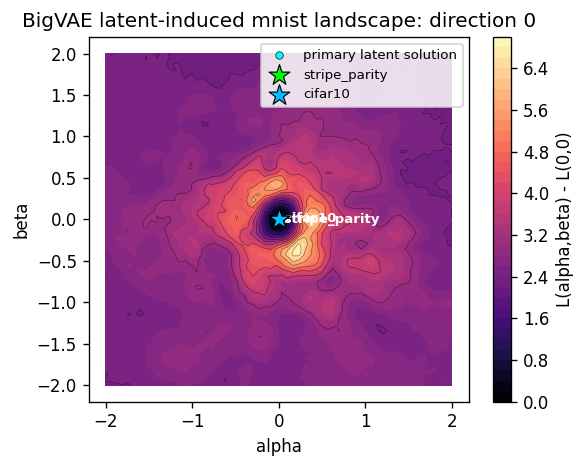

VAE latent tiles: 32
VAE decoded linear params: 93408
VAE latent params: 16384
VAE effective decoded/latent: 5.701171875
initializing VAE latent base point from BigVAE encoder posterior mean
encoded latent tile 1/32
encoded latent tile 32/32
latent_vae_pre_task_train_loss 2.593851089477539 latent_vae_pre_task_train_acc 0.154296875
training VAE decoder-z latents on primary task loss: mnist
latent task step=1/1600 loss=2.5043 batch_acc=0.1797 val_loss=3.2446 val_acc=0.1064
latent task step=50/1600 loss=2.1418 batch_acc=0.1953 val_loss=2.1712 val_acc=0.1572
latent task step=100/1600 loss=1.6561 batch_acc=0.4141 val_loss=1.6937 val_acc=0.3291
latent task step=150/1600 loss=1.4226 batch_acc=0.5000 val_loss=1.5196 val_acc=0.4404
latent task step=200/1600 loss=1.0363 batch_acc=0.6016 val_loss=1.2617 val_acc=0.5518
latent task step=250/1600 loss=0.6791 batch_acc=0.7891 val_loss=1.0969 val_acc=0.6318
latent task step=300/1600 loss=0.4869 batch_acc=0.8594 val_loss=1.0560 val_acc=0.6699
latent ta

,kind,direction_idx,rho,S_rho,M_rho,disk_grid_points,A_tau=0.01_rho,A_frac_tau=0.01_rho,A_tau=0.05_rho,A_frac_tau=0.05_rho,A_tau=0.1_rho,A_frac_tau=0.1_rho
0,latent_vae,0,0.25,1.713694,0.571011,52,0.0172,0.076923,0.042999,0.192308,0.055899,0.250000
1,latent_vae,0,0.50,6.103028,2.664785,180,0.0172,0.022222,0.042999,0.055556,0.055899,0.072222
2,latent_vae,0,0.75,7.257420,3.918486,408,0.0172,0.009804,0.042999,0.024510,0.055899,0.031863
3,latent_vae,0,1.00,7.257420,3.758998,732,0.0172,0.005464,0.042999,0.013661,0.055899,0.017760
4,latent_vae,1,0.25,1.396247,0.438807,52,0.0172,0.076923,0.047299,0.211538,0.055899,0.250000
5,latent_vae,1,0.50,5.344085,2.305286,180,0.0172,0.022222,0.047299,0.061111,0.055899,0.072222
6,latent_vae,1,0.75,5.890870,3.563056,408,0.0172,0.009804,0.047299,0.026961,0.055899,0.031863
7,latent_vae,1,1.00,5.890870,3.625165,732,0.0172,0.005464,0.047299,0.015027,0.055899,0.017760
8,latent_vae,2,0.25,2.980293,0.896258,52,0.0172,0.076923,0.017200,0.076923,0.038699,0.173077
9,latent_vae,2,0.50,7.209742,3.385492,180,0.0172,0.022222,0.017200,0.022222,0.038699,0.050000


diffusion prior initialized patch_embed.weight
diffusion prior initialized blocks.0.attn.in_proj_weight
diffusion prior initialized blocks.0.attn.out_proj.weight
diffusion prior initialized blocks.0.mlp.0.weight
diffusion prior initialized blocks.0.mlp.2.weight
diffusion prior initialized blocks.1.attn.in_proj_weight
diffusion prior initialized blocks.1.attn.out_proj.weight
diffusion prior initialized blocks.1.mlp.0.weight
diffusion prior initialized blocks.1.mlp.2.weight
diffusion prior initialized head.weight


,task_name,label,color,alpha,beta,loss,delta,delta_norm,projection_residual_norm,projection_residual_frac,gram_det
0,autoregressive_diffusion_prior,autoregressive diffusion prior,cyan,-0.006974,-0.004992,0.000654,0.000022,279.471865,279.462156,0.999965,5.499361e+09


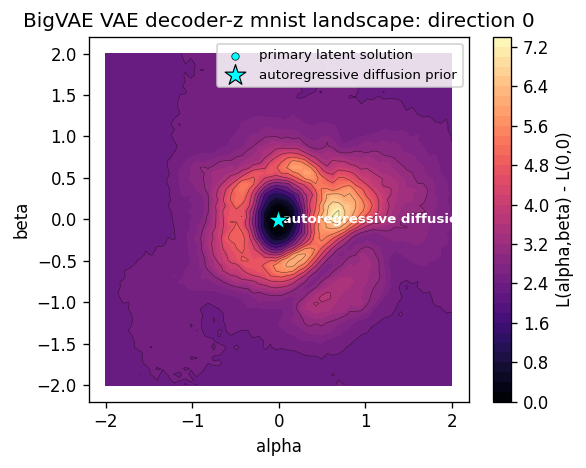

In [8]:
latent_results = []
latent_metrics = pd.DataFrame()
latent_transfer_points: list[dict[str, Any]] = []
latent_transfer_metrics = pd.DataFrame()
latent_vae_results = []
latent_vae_metrics = pd.DataFrame()
latent_vae_reference_points: list[dict[str, Any]] = []
latent_diffusion_prior_projection = pd.DataFrame()

if not BIG_VAE_AE_CHECKPOINT and not BIG_VAE_VAE_CHECKPOINT:
    print('No BigVAE checkpoint is set; skipping latent-induced landscapes.')
else:
    latent_diffusion_prior = None
    if cfg.latent_diffusion_prior_checkpoint:
        latent_diffusion_prior = load_frozen_layer_latent_diffusion_prior(
            cfg.latent_diffusion_prior_checkpoint,
            device=device,
        )

    big_vae_ae = None
    if bool(cfg.latent_ae_landscape_enabled):
        if not BIG_VAE_AE_CHECKPOINT:
            print('AE BigVAE checkpoint is empty; skipping AE latent landscape.')
        else:
            big_vae_ae = load_frozen_big_vae(BIG_VAE_AE_CHECKPOINT, device)
            print('loaded AE BigVAE checkpoint:', BIG_VAE_AE_CHECKPOINT)

    big_vae_vae = None
    if bool(cfg.latent_vae_landscape_enabled):
        if not BIG_VAE_VAE_CHECKPOINT:
            print('VAE BigVAE checkpoint is empty; skipping VAE latent landscape.')
        else:
            big_vae_vae = load_frozen_big_vae(BIG_VAE_VAE_CHECKPOINT, device)
            print('loaded VAE BigVAE checkpoint:', BIG_VAE_VAE_CHECKPOINT)
            if cfg.latent_diffusion_prior_checkpoint and load_distribution_encoder_state_from_latent_diffusion_prior_checkpoint is not None:
                loaded_dist_encoder = load_distribution_encoder_state_from_latent_diffusion_prior_checkpoint(
                    cfg.latent_diffusion_prior_checkpoint,
                    big_vae=big_vae_vae,
                )
                if loaded_dist_encoder:
                    print('loaded finetuned distribution encoder from latent diffusion prior checkpoint into VAE BigVAE')

    if bool(cfg.latent_ae_landscape_enabled) and big_vae_ae is not None:
        adapter = BigVAELatentAdapter(big_vae_ae, base_state, cfg, latent_space='encoder_slots').to(device)
        print('AE latent tiles:', len(adapter.tiles))
        print('AE decoded linear params:', adapter.decoded_numel())
        print('AE latent params:', adapter.latent_numel())
        print('AE effective decoded/latent:', adapter.decoded_numel() / max(1, adapter.latent_numel()))

        mode = str(cfg.latent_base_mode).strip().lower()
        if mode not in {'encoder', 'fit', 'encoder_fit', 'random'}:
            raise ValueError(f'unsupported latent_base_mode={cfg.latent_base_mode!r}')
        if mode in {'encoder', 'encoder_fit'}:
            print('initializing AE latent base point from BigVAE encoder')
            adapter.initialize_latents_from_encoder(base_state, encoder_contexts)
        if mode in {'fit', 'encoder_fit'} and int(cfg.latent_fit_steps) > 0:
            print('refining AE latent base point by decoded-weight MSE')
            fit_latents_to_base(adapter, base_state, cfg.latent_fit_steps, cfg.latent_fit_lr)

        latent_template_model = TinyStripeParityViT(cfg).to(device)
        latent_template_model.load_state_dict(base_state, strict=True)
        latent_pre_task_loss, latent_pre_task_acc = evaluate_latent_adapter(
            adapter,
            latent_template_model,
            landscape_loader,
            max_batches=landscape_max_batches,
        )
        print(f'latent_pre_task_{landscape_split}_loss', latent_pre_task_loss, f'latent_pre_task_{landscape_split}_acc', latent_pre_task_acc)
        print(f'training AE latent slots on primary task loss: {cfg.task_name}')
        train_latents_on_task(
            adapter,
            latent_template_model,
            train_loader,
            val_loader,
            cfg,
            max_eval_batches=landscape_max_batches,
        )

        latent_center_state = clone_latent_state(adapter)
        latent_base_state = adapter.materialize_state()
        latent_model = TinyStripeParityViT(cfg).to(device)
        latent_model.load_state_dict(latent_base_state, strict=True)
        latent_base_loss, latent_base_acc = evaluate_loss(latent_model, landscape_loader, max_batches=landscape_max_batches)
        print(f'latent_base_{landscape_split}_loss', latent_base_loss, f'latent_base_{landscape_split}_acc', latent_base_acc)
        latent_pairs = make_latent_direction_pairs(adapter, cfg.num_directions, cfg.seed + 2000)

        def latent_eval_fn(pair, alpha: float, beta: float) -> float:
            d1, d2 = pair
            override = {
                key: adapter.latents[key] + float(alpha) * d1[key] + float(beta) * d2[key]
                for key in adapter.latents.keys()
            }
            state = adapter.materialize_state(override)
            latent_model.load_state_dict(state, strict=True)
            loss, _acc = evaluate_loss(latent_model, landscape_loader, max_batches=landscape_max_batches)
            return loss

        latent_results = evaluate_landscape(
            kind='latent',
            direction_pairs=latent_pairs,
            base_loss=latent_base_loss,
            eval_fn=latent_eval_fn,
            grid_points=cfg.grid_points,
            rho_max=cfg.rho_max,
        )
        latent_metrics = compute_landscape_metrics(latent_results, cfg.rho_values, cfg.tau_values)
        display(latent_metrics)

        if bool(cfg.latent_transfer_enabled) and latent_results and latent_pairs:
            transfer_rows: list[dict[str, Any]] = []
            transfer_tasks = resolve_latent_transfer_tasks(cfg)
            transfer_train_cfg = make_latent_transfer_train_cfg(cfg)
            transfer_colors = ['lime', 'deepskyblue', 'yellow', 'white']
            print('latent transfer tasks:', transfer_tasks)
            for transfer_idx, transfer_task in enumerate(transfer_tasks):
                print(f'\n=== latent transfer task: {transfer_task} ===')
                (
                    transfer_train_loader,
                    transfer_val_loader,
                    transfer_info,
                    transfer_loader_cfg,
                    natural_transfer_cfg,
                ) = make_arch_compatible_task_loaders(transfer_task, cfg)
                print('transfer natural channels/classes:', natural_transfer_cfg.image_channels, natural_transfer_cfg.num_classes)
                print('transfer model channels/classes:', transfer_loader_cfg.image_channels, transfer_loader_cfg.num_classes)
                print('transfer label balance train:', torch.bincount(transfer_info['train_labels'], minlength=cfg.num_classes).tolist())
                print('transfer label balance val:', torch.bincount(transfer_info['val_labels'], minlength=cfg.num_classes).tolist())

                transfer_adapter = BigVAELatentAdapter(big_vae_ae, base_state, cfg, latent_space='encoder_slots').to(device)
                load_latent_state_(transfer_adapter, latent_center_state)
                transfer_template_model = TinyStripeParityViT(cfg).to(device)
                transfer_template_model.load_state_dict(latent_base_state, strict=True)
                transfer_landscape_loader = transfer_train_loader if landscape_split == 'train' else transfer_val_loader
                transfer_start_loss, transfer_start_acc = evaluate_latent_adapter(
                    transfer_adapter,
                    transfer_template_model,
                    transfer_landscape_loader,
                    max_batches=landscape_max_batches,
                )
                print(
                    f'transfer_start_{landscape_split}_loss={transfer_start_loss:.4f} '
                    f'transfer_start_{landscape_split}_acc={transfer_start_acc:.4f}'
                )
                train_latents_on_task(
                    transfer_adapter,
                    transfer_template_model,
                    transfer_train_loader,
                    transfer_val_loader,
                    transfer_train_cfg,
                    max_eval_batches=landscape_max_batches,
                )
                transfer_solution_state = clone_latent_state(transfer_adapter)
                transfer_final_loss, transfer_final_acc = evaluate_latent_adapter(
                    transfer_adapter,
                    transfer_template_model,
                    transfer_landscape_loader,
                    max_batches=landscape_max_batches,
                )
                projection = project_latent_solution_to_pair(
                    center=latent_center_state,
                    solution=transfer_solution_state,
                    pair=latent_pairs[0],
                )
                projected_primary_loss = latent_eval_fn(latent_pairs[0], projection['alpha'], projection['beta'])
                point = {
                    'task_name': transfer_task,
                    'label': transfer_task,
                    'color': transfer_colors[transfer_idx % len(transfer_colors)],
                    'alpha': projection['alpha'],
                    'beta': projection['beta'],
                    'loss': float(projected_primary_loss),
                    'delta': float(projected_primary_loss - latent_base_loss),
                    'transfer_start_loss': float(transfer_start_loss),
                    'transfer_start_acc': float(transfer_start_acc),
                    'transfer_final_loss': float(transfer_final_loss),
                    'transfer_final_acc': float(transfer_final_acc),
                    **projection,
                }
                latent_transfer_points.append(point)
                transfer_rows.append(point)
                print(
                    f'projected {transfer_task}: alpha={point["alpha"]:.4f} beta={point["beta"]:.4f} '
                    f'primary_delta={point["delta"]:.4f} residual_frac={point["projection_residual_frac"]:.4f} '
                    f'transfer_final_loss={transfer_final_loss:.4f} transfer_final_acc={transfer_final_acc:.4f}'
                )
            latent_transfer_metrics = pd.DataFrame(transfer_rows)
            display(latent_transfer_metrics)

        plot_landscape(
            latent_results[0],
            f'BigVAE latent-induced {cfg.task_name} landscape: direction 0',
            save_path=artifact_dir / 'latent_direction_0_2d.png',
            markers=latent_transfer_points,
        )
        plot_landscape_3d(
            latent_results[0],
            f'Interactive 3D BigVAE latent-induced {cfg.task_name} landscape: direction 0',
            save_html_path=artifact_dir / 'latent_direction_0_3d.html',
            markers=latent_transfer_points,
        )

    if bool(cfg.latent_vae_landscape_enabled) and big_vae_vae is not None:
        if not bool(getattr(big_vae_vae.cfg.big_vae, 'use_latent_sampling', False)):
            print('VAE checkpoint has use_latent_sampling=false; skipping VAE latent landscape.')
        else:
            vae_adapter = BigVAELatentAdapter(
                big_vae_vae,
                base_state,
                cfg,
                latent_space='decoder_z',
                latent_diffusion_prior=latent_diffusion_prior,
            ).to(device)
            print('VAE latent tiles:', len(vae_adapter.tiles))
            print('VAE decoded linear params:', vae_adapter.decoded_numel())
            print('VAE latent params:', vae_adapter.latent_numel())
            print('VAE effective decoded/latent:', vae_adapter.decoded_numel() / max(1, vae_adapter.latent_numel()))

            mode = str(cfg.latent_base_mode).strip().lower()
            if mode not in {'encoder', 'fit', 'encoder_fit', 'random'}:
                raise ValueError(f'unsupported latent_base_mode={cfg.latent_base_mode!r}')
            if mode in {'encoder', 'encoder_fit'}:
                print('initializing VAE latent base point from BigVAE encoder posterior mean')
                vae_adapter.initialize_latents_from_encoder(base_state, encoder_contexts)
            if mode in {'fit', 'encoder_fit'} and int(cfg.latent_fit_steps) > 0:
                print('refining VAE latent base point by decoded-weight MSE')
                fit_latents_to_base(vae_adapter, base_state, cfg.latent_fit_steps, cfg.latent_fit_lr)

            vae_template_model = TinyStripeParityViT(cfg).to(device)
            vae_template_model.load_state_dict(base_state, strict=True)
            vae_pre_task_loss, vae_pre_task_acc = evaluate_latent_adapter(
                vae_adapter,
                vae_template_model,
                landscape_loader,
                max_batches=landscape_max_batches,
            )
            print(f'latent_vae_pre_task_{landscape_split}_loss', vae_pre_task_loss, f'latent_vae_pre_task_{landscape_split}_acc', vae_pre_task_acc)
            print(f'training VAE decoder-z latents on primary task loss: {cfg.task_name}')
            train_latents_on_task(
                vae_adapter,
                vae_template_model,
                train_loader,
                val_loader,
                cfg,
                max_eval_batches=landscape_max_batches,
            )

            vae_center_state = clone_latent_state(vae_adapter)
            vae_base_state = vae_adapter.materialize_state()
            vae_model = TinyStripeParityViT(cfg).to(device)
            vae_model.load_state_dict(vae_base_state, strict=True)
            vae_base_loss, vae_base_acc = evaluate_loss(vae_model, landscape_loader, max_batches=landscape_max_batches)
            print(f'latent_vae_base_{landscape_split}_loss', vae_base_loss, f'latent_vae_base_{landscape_split}_acc', vae_base_acc)
            vae_pairs = make_latent_direction_pairs(vae_adapter, cfg.num_directions, cfg.seed + 3000)

            def latent_vae_eval_fn(pair, alpha: float, beta: float) -> float:
                d1, d2 = pair
                override = {
                    key: vae_adapter.latents[key] + float(alpha) * d1[key] + float(beta) * d2[key]
                    for key in vae_adapter.latents.keys()
                }
                state = vae_adapter.materialize_state(override)
                vae_model.load_state_dict(state, strict=True)
                loss, _acc = evaluate_loss(vae_model, landscape_loader, max_batches=landscape_max_batches)
                return loss

            latent_vae_results = evaluate_landscape(
                kind='latent_vae',
                direction_pairs=vae_pairs,
                base_loss=vae_base_loss,
                eval_fn=latent_vae_eval_fn,
                grid_points=cfg.grid_points,
                rho_max=cfg.rho_max,
            )
            latent_vae_metrics = compute_landscape_metrics(latent_vae_results, cfg.rho_values, cfg.tau_values)
            display(latent_vae_metrics)

            if latent_diffusion_prior is not None:
                calibration_images = collect_calibration_images(train_loader, int(cfg.latent_diffusion_prior_calibration_batches))
                prior_adapter = BigVAELatentAdapter(
                    big_vae_vae,
                    base_state,
                    cfg,
                    latent_space='decoder_z',
                    latent_diffusion_prior=latent_diffusion_prior,
                ).to(device)
                prior_scaffold_model = TinyStripeParityViT(cfg).to(device)
                prior_scaffold_model.load_state_dict(base_state, strict=True)
                prior_adapter.initialize_from_diffusion_prior_autoregressive(
                    prior_scaffold_model,
                    calibration_images=calibration_images,
                    prior_steps=int(cfg.latent_diffusion_prior_steps),
                    prior_sampler=str(cfg.latent_diffusion_prior_sampler),
                    prior_eta=float(cfg.latent_diffusion_prior_eta),
                )
                prior_solution_state = clone_latent_state(prior_adapter)
                projection = project_latent_solution_to_pair(
                    center=vae_center_state,
                    solution=prior_solution_state,
                    pair=vae_pairs[0],
                )
                projected_primary_loss = latent_vae_eval_fn(vae_pairs[0], projection['alpha'], projection['beta'])
                prior_point = {
                    'task_name': 'autoregressive_diffusion_prior',
                    'label': 'autoregressive diffusion prior',
                    'color': 'cyan',
                    'alpha': projection['alpha'],
                    'beta': projection['beta'],
                    'loss': float(projected_primary_loss),
                    'delta': float(projected_primary_loss - vae_base_loss),
                    **projection,
                }
                latent_vae_reference_points.append(prior_point)
                latent_diffusion_prior_projection = pd.DataFrame([prior_point])
                display(latent_diffusion_prior_projection)

            plot_landscape(
                latent_vae_results[0],
                f'BigVAE VAE decoder-z {cfg.task_name} landscape: direction 0',
                save_path=artifact_dir / 'latent_vae_direction_0_2d.png',
                markers=latent_vae_reference_points,
            )
            plot_landscape_3d(
                latent_vae_results[0],
                f'Interactive 3D BigVAE VAE decoder-z {cfg.task_name} landscape: direction 0',
                save_html_path=artifact_dir / 'latent_vae_direction_0_3d.html',
                markers=latent_vae_reference_points,
            )


,kind,direction_idx,rho,S_rho,M_rho,disk_grid_points,A_tau=0.01_rho,A_frac_tau=0.01_rho,A_tau=0.05_rho,A_frac_tau=0.05_rho,A_tau=0.1_rho,A_frac_tau=0.1_rho
0,raw_fn,0,0.25,2.397771,0.664525,52,0.030099,0.134615,0.047299,0.211538,0.060199,0.269231
1,raw_fn,0,0.50,6.745204,3.066874,180,0.030099,0.038889,0.047299,0.061111,0.060199,0.077778
2,raw_fn,0,0.75,7.839415,4.578856,408,0.030099,0.017157,0.047299,0.026961,0.060199,0.034314
3,raw_fn,0,1.00,7.839415,5.006875,732,0.030099,0.009563,0.047299,0.015027,0.060199,0.019126
4,raw_fn,1,0.25,1.762478,0.632998,52,0.021500,0.096154,0.038699,0.173077,0.055899,0.250000
5,raw_fn,1,0.50,5.875952,2.708672,180,0.021500,0.027778,0.038699,0.050000,0.055899,0.072222
6,raw_fn,1,0.75,8.170235,4.344046,408,0.021500,0.012255,0.038699,0.022059,0.055899,0.031863
7,raw_fn,1,1.00,8.198047,4.939936,732,0.021500,0.006831,0.038699,0.012295,0.055899,0.017760
8,raw_fn,2,0.25,1.713684,0.586035,52,0.025800,0.115385,0.042999,0.192308,0.060199,0.269231
9,raw_fn,2,0.50,7.141779,2.894085,180,0.025800,0.033333,0.042999,0.055556,0.060199,0.077778


/home/coder/tmp/ipykernel_2882623/4035020041.py:265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showmeans=True)


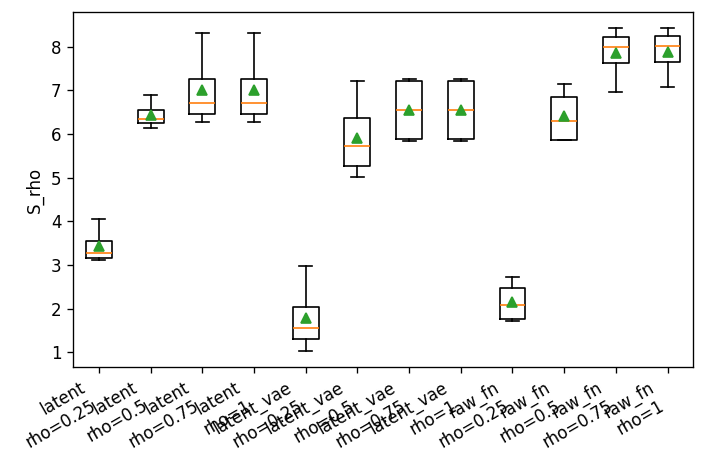

/home/coder/tmp/ipykernel_2882623/4035020041.py:265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showmeans=True)


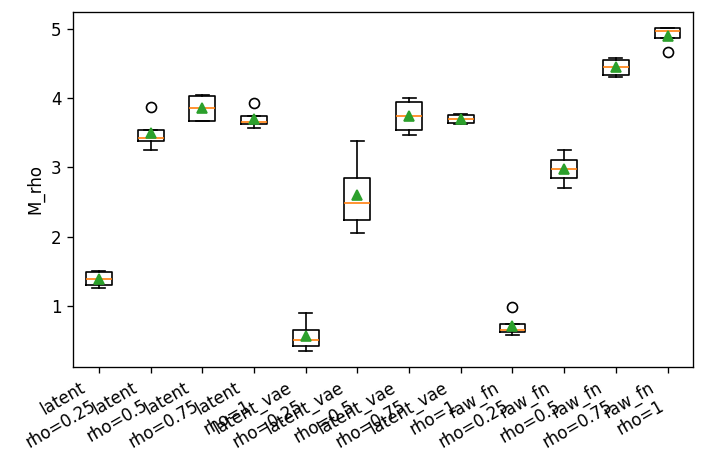

/home/coder/tmp/ipykernel_2882623/4035020041.py:265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showmeans=True)


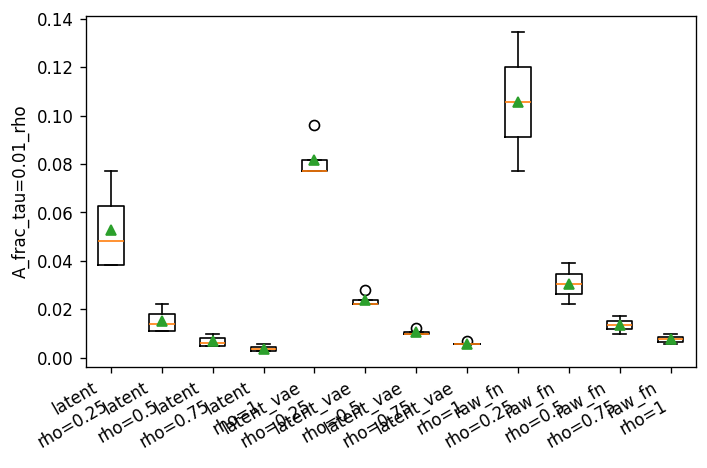

/home/coder/tmp/ipykernel_2882623/4035020041.py:265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showmeans=True)


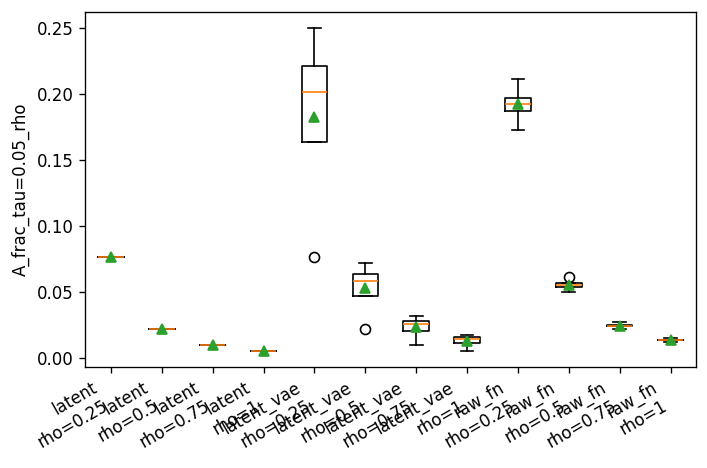

/home/coder/tmp/ipykernel_2882623/4035020041.py:265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showmeans=True)


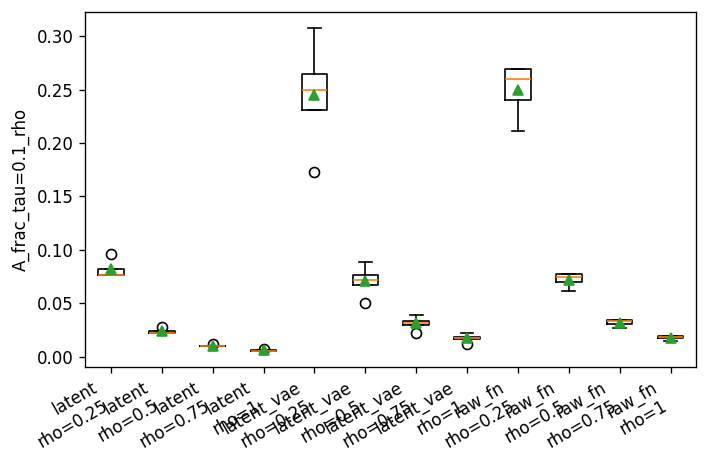

saved metrics to artifacts/loss_landscape_diffusion/landscape_metrics.csv
saved latent transfer projections to artifacts/loss_landscape_diffusion/latent_transfer_projection_points.csv
saved diffusion prior projection to artifacts/loss_landscape_diffusion/latent_diffusion_prior_projection_point.csv
saved raw/latent grids to artifacts/loss_landscape_diffusion/landscape_results.npz


In [9]:
metric_frames = [raw_metrics]
if len(latent_metrics):
    metric_frames.append(latent_metrics)
if len(latent_vae_metrics):
    metric_frames.append(latent_vae_metrics)
all_metrics = pd.concat(metric_frames, ignore_index=True)
display(all_metrics)

plot_metric_boxplots(all_metrics, 'S_rho', save_path=artifact_dir / 'metric_S_rho_boxplot.png')
plot_metric_boxplots(all_metrics, 'M_rho', save_path=artifact_dir / 'metric_M_rho_boxplot.png')
for tau in cfg.tau_values:
    col = f'A_frac_tau={tau:g}_rho'
    if col in all_metrics.columns:
        plot_metric_boxplots(all_metrics, col, save_path=artifact_dir / f'metric_{col.replace("=", "_").replace(".", "p")}_boxplot.png')

out_dir = artifact_dir
out_dir.mkdir(parents=True, exist_ok=True)
all_metrics.to_csv(out_dir / 'landscape_metrics.csv', index=False)
if len(latent_transfer_metrics):
    latent_transfer_metrics.to_csv(out_dir / 'latent_transfer_projection_points.csv', index=False)
if len(latent_diffusion_prior_projection):
    latent_diffusion_prior_projection.to_csv(out_dir / 'latent_diffusion_prior_projection_point.csv', index=False)

save_payload: dict[str, Any] = {}
for result in raw_results:
    save_payload[f'raw_losses_direction_{result.direction_idx}'] = result.losses
for result in latent_results:
    save_payload[f'latent_losses_direction_{result.direction_idx}'] = result.losses
for result in latent_vae_results:
    save_payload[f'latent_vae_losses_direction_{result.direction_idx}'] = result.losses
if raw_results:
    save_payload['raw_alphas'] = raw_results[0].alphas
    save_payload['raw_betas'] = raw_results[0].betas
    save_payload['raw_base_loss'] = np.array([raw_results[0].base_loss], dtype=np.float64)
if latent_results:
    save_payload['latent_alphas'] = latent_results[0].alphas
    save_payload['latent_betas'] = latent_results[0].betas
    save_payload['latent_base_loss'] = np.array([latent_results[0].base_loss], dtype=np.float64)
if latent_vae_results:
    save_payload['latent_vae_alphas'] = latent_vae_results[0].alphas
    save_payload['latent_vae_betas'] = latent_vae_results[0].betas
    save_payload['latent_vae_base_loss'] = np.array([latent_vae_results[0].base_loss], dtype=np.float64)
if latent_transfer_points:
    save_payload['latent_transfer_task_names'] = np.array([point['task_name'] for point in latent_transfer_points])
    save_payload['latent_transfer_alpha'] = np.array([point['alpha'] for point in latent_transfer_points], dtype=np.float64)
    save_payload['latent_transfer_beta'] = np.array([point['beta'] for point in latent_transfer_points], dtype=np.float64)
    save_payload['latent_transfer_primary_loss'] = np.array([point['loss'] for point in latent_transfer_points], dtype=np.float64)
    save_payload['latent_transfer_primary_delta'] = np.array([point['delta'] for point in latent_transfer_points], dtype=np.float64)
    save_payload['latent_transfer_projection_residual_frac'] = np.array(
        [point['projection_residual_frac'] for point in latent_transfer_points],
        dtype=np.float64,
    )
if latent_vae_reference_points:
    save_payload['latent_vae_reference_labels'] = np.array([point['label'] for point in latent_vae_reference_points])
    save_payload['latent_vae_reference_alpha'] = np.array([point['alpha'] for point in latent_vae_reference_points], dtype=np.float64)
    save_payload['latent_vae_reference_beta'] = np.array([point['beta'] for point in latent_vae_reference_points], dtype=np.float64)
    save_payload['latent_vae_reference_loss'] = np.array([point['loss'] for point in latent_vae_reference_points], dtype=np.float64)
    save_payload['latent_vae_reference_delta'] = np.array([point['delta'] for point in latent_vae_reference_points], dtype=np.float64)
np.savez_compressed(out_dir / 'landscape_results.npz', **save_payload)
print('saved metrics to', out_dir / 'landscape_metrics.csv')
if len(latent_transfer_metrics):
    print('saved latent transfer projections to', out_dir / 'latent_transfer_projection_points.csv')
if len(latent_diffusion_prior_projection):
    print('saved diffusion prior projection to', out_dir / 'latent_diffusion_prior_projection_point.csv')
print('saved raw/latent grids to', out_dir / 'landscape_results.npz')


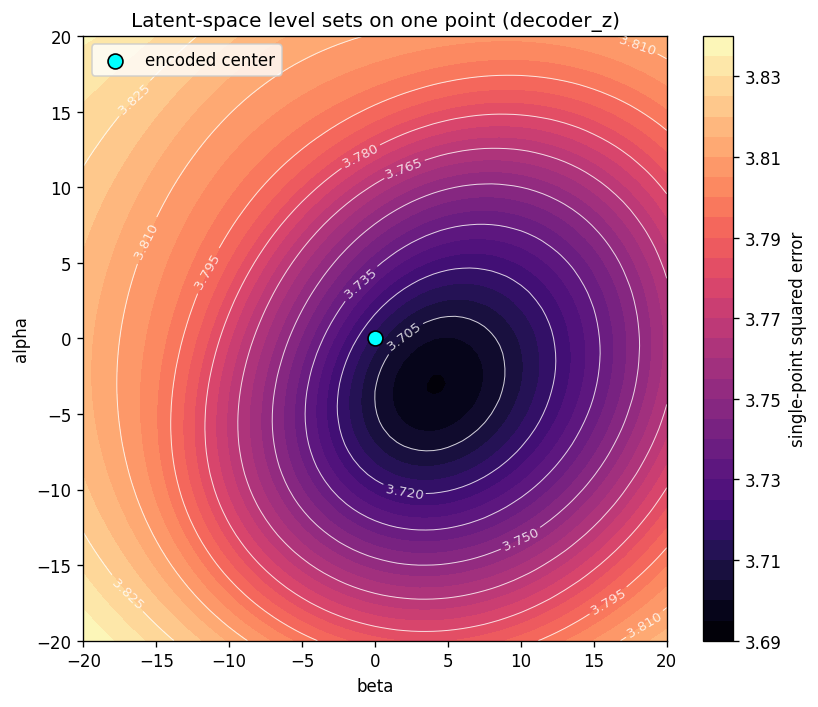

x* = [[ 0.7 -1.1  1. ]]
y* = [[2.0200002]]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------
# pick loaded BigVAE
# -------------------------
if 'big_vae_vae' in globals() and big_vae_vae is not None:
    big_vae = big_vae_vae
    latent_space = 'decoder_z'
elif 'big_vae_ae' in globals() and big_vae_ae is not None:
    big_vae = big_vae_ae
    latent_space = 'encoder_slots'
else:
    raise RuntimeError("Run the notebook cell that loads big_vae_vae / big_vae_ae first.")

device = next(big_vae.parameters()).device
dtype = torch.float32
big_vae.eval()

# -------------------------
# one linear regressor
# y = w1*x1 + w2*x2 + b
# bias encoded as third feature = 1
# -------------------------
W_true = torch.tensor(
    [
        [1.2],
        [-0.8],
        [0.3],
    ],
    device=device,
    dtype=dtype,
)

# one single input point
x_star = torch.tensor([[0.7, -1.1, 1.0]], device=device, dtype=dtype)   # [1, 3]
y_star = x_star @ W_true                                                 # [1, 1]

# context X for distribution encoder
# можно просто повторить эту же точку много раз, чтобы encoder получил batch rows
X_context = x_star.repeat(128, 1)   # [N, 3]

W_b = W_true.unsqueeze(0)           # [1, 3, 1]
X_b = X_context.unsqueeze(0)        # [1, N, 3]

d_in = 3
d_out = 1
d_in_mask = torch.ones(1, d_in, device=device, dtype=torch.bool)
d_out_mask = torch.ones(1, d_out, device=device, dtype=torch.bool)

# -------------------------
# build condition from X
# -------------------------
T, d_in_pad, patch_mask, _struct_mask, dist_var_by_patch, dist_patch_by_patch, dist_var_pooled = (
    big_vae._encode_distribution_context(
        X_b,
        x_mask=None,
        d_in_mask=d_in_mask,
    )
)

# -------------------------
# encode W_true -> latent center z0
# -------------------------
latent_slots = big_vae._encode_latent_slots(
    W_b,
    T=T,
    d_in_pad=d_in_pad,
    patch_mask=patch_mask,
    d_out_mask=d_out_mask,
    dist_var_by_patch=dist_var_by_patch,
    dist_patch_by_patch=dist_patch_by_patch,
    dist_var_pooled=dist_var_pooled,
)

if latent_space == 'decoder_z':
    base_z = big_vae.latent_norm(latent_slots.reshape(1, -1))
    z0_flat, mu_flat, logvar_flat = big_vae._sample_latent_posterior(base_z)
    z0 = z0_flat.view_as(latent_slots).detach()
else:
    z0 = latent_slots.detach()

@torch.no_grad()
def decode_weight_from_latent(z):
    if latent_space == 'decoder_z':
        W_hat, *_ = big_vae._decode_from_decoder_latent(
            z,
            dist_patch_by_patch=dist_patch_by_patch,
            patch_mask=patch_mask,
            d_in_mask=d_in_mask,
            d_out_mask=d_out_mask,
            d_in=d_in,
            d_out=d_out,
            d_in_pad=d_in_pad,
            T=T,
        )
    else:
        W_hat, *_ = big_vae._decode_from_latent_slots(
            z,
            dist_patch_by_patch=dist_patch_by_patch,
            patch_mask=patch_mask,
            d_in_mask=d_in_mask,
            d_out_mask=d_out_mask,
            d_in=d_in,
            d_out=d_out,
            d_in_pad=d_in_pad,
            T=T,
        )
    return W_hat[0]   # [3, 1]

# -------------------------
# two latent directions
# -------------------------
d1 = torch.randn_like(z0)
d1 = d1 / d1.norm()

d2 = torch.randn_like(z0)
d2 = d2 - (d2 * d1).sum() * d1
d2 = d2 / d2.norm()

# -------------------------
# scalar loss on one point
# -------------------------
alphas = torch.linspace(-20.0, 20.0, 81, device=device)
betas = torch.linspace(-20.0, 20.0, 81, device=device)

loss_grid = torch.zeros(len(alphas), len(betas), device=device, dtype=dtype)

for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        z = z0 + a * d1 + b * d2
        W_hat = decode_weight_from_latent(z)      # [3, 1]
        y_hat = x_star @ W_hat                    # [1, 1]
        loss = (y_hat - y_star).pow(2).mean()
        loss_grid[i, j] = loss

loss_grid_np = loss_grid.detach().cpu().numpy()
A, B = np.meshgrid(betas.detach().cpu().numpy(), alphas.detach().cpu().numpy())

plt.figure(figsize=(7, 6))
cf = plt.contourf(B, A, loss_grid_np, levels=30, cmap='magma')
cs = plt.contour(B, A, loss_grid_np, levels=12, colors='white', linewidths=0.6, alpha=0.8)
plt.clabel(cs, inline=True, fontsize=8)
plt.colorbar(cf, label='single-point squared error')
plt.scatter([0.0], [0.0], c='cyan', s=80, edgecolors='black', label='encoded center')
plt.xlabel('beta')
plt.ylabel('alpha')
plt.title(f'Latent-space level sets on one point ({latent_space})')
plt.legend()
plt.tight_layout()
plt.show()

print("x* =", x_star.detach().cpu().numpy())
print("y* =", y_star.detach().cpu().numpy())


step=0000 loss=3.71311188 grad_norm=6.18063100e-02 grad_abs_mean=1.20999466e-03 grad_abs_max=3.09298094e-02
step=0050 loss=0.32561189 grad_norm=4.59203124e-02 grad_abs_mean=4.10102570e-04 grad_abs_max=2.74742320e-02
step=0100 loss=0.14086194 grad_norm=1.48308547e-02 grad_abs_mean=1.04030900e-04 grad_abs_max=8.97789467e-03
step=0150 loss=0.07530779 grad_norm=6.56127231e-03 grad_abs_mean=3.97837357e-05 grad_abs_max=3.94934881e-03
step=0200 loss=0.04005259 grad_norm=2.98766652e-03 grad_abs_mean=1.83265674e-05 grad_abs_max=1.73443428e-03
step=0250 loss=0.02144035 grad_norm=1.44422345e-03 grad_abs_mean=1.02445947e-05 grad_abs_max=8.10935104e-04
step=0300 loss=0.01164190 grad_norm=7.12063920e-04 grad_abs_mean=4.84298153e-06 grad_abs_max=3.91795940e-04
step=0350 loss=0.00635684 grad_norm=3.76153970e-04 grad_abs_mean=2.87285138e-06 grad_abs_max=2.12144994e-04
step=0400 loss=0.00346945 grad_norm=2.05711418e-04 grad_abs_mean=1.75960520e-06 grad_abs_max=1.16114861e-04
step=0450 loss=0.00184227 gr

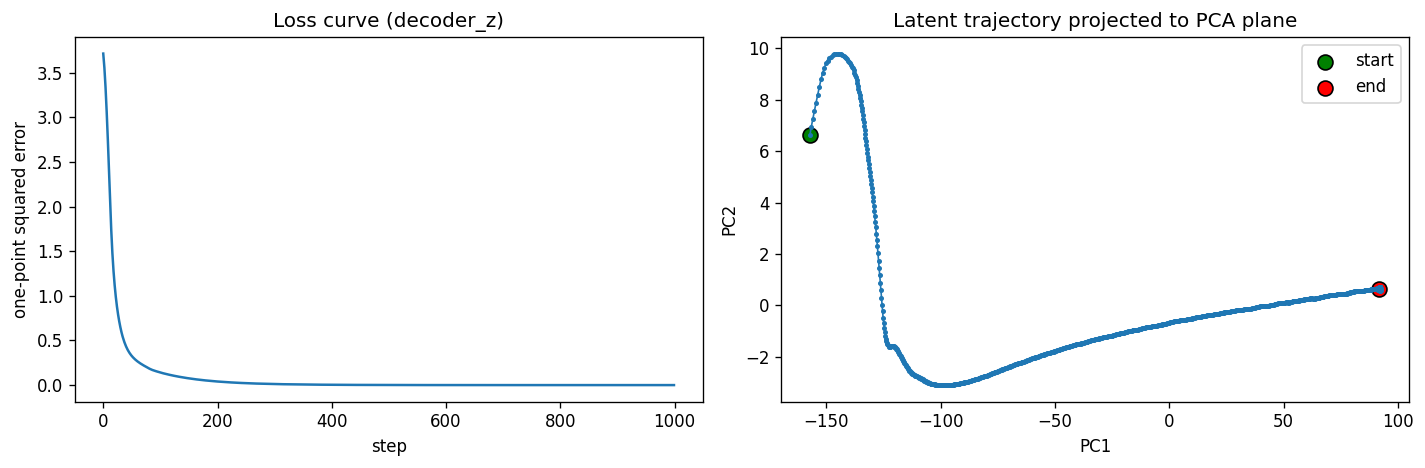

W_true:
tensor([[ 1.2000],
        [-0.8000],
        [ 0.3000]])
W_final:
tensor([[ 0.2695],
        [-0.9886],
        [ 0.7440]])
y_star: [[2.0200002]]
y_hat : [[2.0199885]]


In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -------------------------
# pick loaded BigVAE
# -------------------------
if 'big_vae_vae' in globals() and big_vae_vae is not None:
    big_vae = big_vae_vae
    latent_space = 'decoder_z'
elif 'big_vae_ae' in globals() and big_vae_ae is not None:
    big_vae = big_vae_ae
    latent_space = 'encoder_slots'
else:
    raise RuntimeError("Run the notebook cell that loads big_vae_vae / big_vae_ae first.")

device = next(big_vae.parameters()).device
dtype = torch.float32
big_vae.eval()

# -------------------------
# target one-point regression
# -------------------------
W_true = torch.tensor(
    [
        [1.2],
        [-0.8],
        [0.3],
    ],
    device=device,
    dtype=dtype,
)

x_star = torch.tensor([[0.7, -1.1, 1.0]], device=device, dtype=dtype)   # [1, 3]
y_star = x_star @ W_true                                                 # [1, 1]

# context for distribution encoder
X_context = x_star.repeat(128, 1)

W_b = W_true.unsqueeze(0)
X_b = X_context.unsqueeze(0)

d_in = 3
d_out = 1
d_in_mask = torch.ones(1, d_in, device=device, dtype=torch.bool)
d_out_mask = torch.ones(1, d_out, device=device, dtype=torch.bool)

T, d_in_pad, patch_mask, _struct_mask, dist_var_by_patch, dist_patch_by_patch, dist_var_pooled = (
    big_vae._encode_distribution_context(
        X_b,
        x_mask=None,
        d_in_mask=d_in_mask,
    )
)

latent_slots = big_vae._encode_latent_slots(
    W_b,
    T=T,
    d_in_pad=d_in_pad,
    patch_mask=patch_mask,
    d_out_mask=d_out_mask,
    dist_var_by_patch=dist_var_by_patch,
    dist_patch_by_patch=dist_patch_by_patch,
    dist_var_pooled=dist_var_pooled,
)

if latent_space == 'decoder_z':
    base_z = big_vae.latent_norm(latent_slots.reshape(1, -1))
    z0_flat, _, _ = big_vae._sample_latent_posterior(base_z)
    z0 = z0_flat.view_as(latent_slots).detach()
else:
    z0 = latent_slots.detach()

z = torch.nn.Parameter(z0.clone())

optimizer = torch.optim.Adam([z], lr=1e-1, betas=(0.9, 0.95), eps=1e-9)
loss_history = []
trajectory = []

def decode_weight(z_current):
    if latent_space == 'decoder_z':
        W_hat, *_ = big_vae._decode_from_decoder_latent(
            z_current,
            dist_patch_by_patch=dist_patch_by_patch,
            patch_mask=patch_mask,
            d_in_mask=d_in_mask,
            d_out_mask=d_out_mask,
            d_in=d_in,
            d_out=d_out,
            d_in_pad=d_in_pad,
            T=T,
        )
    else:
        W_hat, *_ = big_vae._decode_from_latent_slots(
            z_current,
            dist_patch_by_patch=dist_patch_by_patch,
            patch_mask=patch_mask,
            d_in_mask=d_in_mask,
            d_out_mask=d_out_mask,
            d_in=d_in,
            d_out=d_out,
            d_in_pad=d_in_pad,
            T=T,
        )
    return W_hat[0]   # [3, 1]

num_steps = 1000

for step in range(num_steps):
    optimizer.zero_grad()

    W_hat = decode_weight(z)
    y_hat = x_star @ W_hat
    loss = (y_hat - y_star).pow(2).mean()

    loss.backward()

    grad_norm = float(z.grad.detach().norm().cpu().item())
    grad_abs_max = float(z.grad.detach().abs().max().cpu().item())
    grad_abs_mean = float(z.grad.detach().abs().mean().cpu().item())

    if step % 50 == 0 or step == num_steps - 1:
        print(
            f"step={step:04d} "
            f"loss={loss.item():.8f} "
            f"grad_norm={grad_norm:.8e} "
            f"grad_abs_mean={grad_abs_mean:.8e} "
            f"grad_abs_max={grad_abs_max:.8e}"
        )

    optimizer.step()

    loss_history.append(float(loss.detach().cpu().item()))
    trajectory.append(z.detach().reshape(-1).cpu().numpy().copy())


W_final = decode_weight(z).detach().cpu()

# -------------------------
# PCA projection of trajectory
# -------------------------
traj = np.stack(trajectory, axis=0)   # [S, D]
traj_center = traj.mean(axis=0, keepdims=True)
traj_centered = traj - traj_center

# SVD-based PCA
U, S, Vt = np.linalg.svd(traj_centered, full_matrices=False)
basis = Vt[:2]                        # [2, D]
traj_2d = traj_centered @ basis.T     # [S, 2]

# -------------------------
# plots
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history)
axes[0].set_xlabel("step")
axes[0].set_ylabel("one-point squared error")
axes[0].set_title(f"Loss curve ({latent_space})")

axes[1].plot(traj_2d[:, 0], traj_2d[:, 1], '-o', markersize=2, linewidth=1)
axes[1].scatter(traj_2d[0, 0], traj_2d[0, 1], c='green', s=80, label='start', edgecolors='black')
axes[1].scatter(traj_2d[-1, 0], traj_2d[-1, 1], c='red', s=80, label='end', edgecolors='black')
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Latent trajectory projected to PCA plane")
axes[1].legend()

plt.tight_layout()
plt.show()

print("W_true:")
print(W_true.detach().cpu())
print("W_final:")
print(W_final)
print("y_star:", y_star.detach().cpu().numpy())
print("y_hat :", (x_star @ W_final.to(device)).detach().cpu().numpy())


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from big_vae.eval.vit_tiny_latent_optimization import (
    BigVAELatentTensorStore,
    FunctionalViTTiny,
    ViTTinyConfig,
    count_trainable_parameters,
    load_frozen_big_vae_decoder,
    make_initial_tensors,
    seed_everything,
)
from post_train_research.vit_latent_scaling.init import export_named_tensors
from training.big_vae_latent_diffusion import (
    load_distribution_encoder_state_from_latent_diffusion_prior_checkpoint,
    load_frozen_layer_latent_diffusion_prior,
)

# ============================================================
# 0. Config
# ============================================================
BIG_VAE_CHECKPOINT = "/home/coder/project/artifacts/training/checkpoints/weight_quantile_vae_gpu0_square_VAE/stage_1/latest.pt"
DIFFUSION_PRIOR_CHECKPOINT = "/home/coder/project/artifacts/training/runs/train_big_vae_latent_diffusion_prior_20260427_032313_pid2515158_cdb92e/checkpoints/big_vae_latent_diffusion_prior/stage_1/latest.pt"

DATA_DIR = "./data/cifar10"
DOWNLOAD = True

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
SEED = 42

# Какие типы весов идут через frozen decoder.
# Допустимые: {"qkv", "proj", "fc1", "fc2", "head"}
LATENT_LAYER_TYPES = {"qkv", "proj", "fc1", "fc2", "head"}

# ВАЖНО: должно совпадать с тем, на чём реально обучались decoder/prior.
BIG_VAE_DECODE = "weights"
BIG_VAE_TILE_T_PATCHES = 4
BIG_VAE_TILE_D_OUT = 64
LATENT_PARAMETERIZATION = "euclidean"   # "euclidean" | "sphere"

DIFFUSION_PRIOR_STEPS = 50
DIFFUSION_PRIOR_SAMPLER = "ddim"
DIFFUSION_PRIOR_ETA = 0.0
CALIBRATION_BATCHES = 1

TRAIN_SUBSET = 10000
TEST_SUBSET = 2000
TRAIN_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512
NUM_STEPS = 400
EVAL_EVERY = 25

LR_RAW = 1e-3
LR_LATENT = 1e-2
WEIGHT_DECAY_RAW = 0.0
WEIGHT_DECAY_LATENT = 0.0
BETAS = (0.9, 0.999)
EPS = 1e-9

# Компактная CIFAR-10 модель под 4x64 tiling.
vit_cfg = ViTTinyConfig(
    image_size=32,
    patch_size=8,
    in_channels=3,
    num_classes=10,
    hidden_dim=64,
    depth=1,
    num_heads=4,
    mlp_ratio=2.0,
    dropout=0.0,
    attention_dropout=0.0,
)

# ============================================================
# 1. Repro
# ============================================================
seed_everything(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# 2. CIFAR-10 data
# ============================================================
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_set_full = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=DOWNLOAD,
    transform=transform,
)
test_set_full = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=DOWNLOAD,
    transform=transform,
)

train_set = Subset(train_set_full, list(range(min(TRAIN_SUBSET, len(train_set_full)))))
test_set = Subset(test_set_full, list(range(min(TEST_SUBSET, len(test_set_full)))))

train_eval_loader = DataLoader(
    train_set,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_set,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)

def build_batch_schedule(dataset_len, batch_size, steps, seed):
    g = torch.Generator(device="cpu")
    g.manual_seed(int(seed))
    schedule = []
    while len(schedule) < int(steps):
        perm = torch.randperm(int(dataset_len), generator=g)
        for start in range(0, int(dataset_len), int(batch_size)):
            schedule.append(perm[start:start + int(batch_size)].clone())
            if len(schedule) >= int(steps):
                break
    return schedule

def fetch_batch(dataset, indices, device):
    images = []
    labels = []
    for idx in indices.tolist():
        image, label = dataset[int(idx)]
        images.append(image)
        labels.append(int(label))
    return (
        torch.stack(images, dim=0).to(device=device, non_blocking=False),
        torch.tensor(labels, device=device),
    )

def collect_calibration_images(dataset, batch_schedule, num_batches, device):
    chunks = []
    for batch_indices in batch_schedule[: max(1, int(num_batches))]:
        images, _ = fetch_batch(dataset, batch_indices, device=device)
        chunks.append(images.detach().cpu())
    return torch.cat(chunks, dim=0).contiguous()

train_schedule = build_batch_schedule(
    dataset_len=len(train_set),
    batch_size=TRAIN_BATCH_SIZE,
    steps=NUM_STEPS,
    seed=SEED,
)

calibration_images = collect_calibration_images(
    train_set,
    train_schedule,
    num_batches=CALIBRATION_BATCHES,
    device=DEVICE,
)

# ============================================================
# 3. Selective latent store with online conditioning refresh
# ============================================================
ALLOWED_LAYER_TYPES = {"qkv", "proj", "fc1", "fc2", "head"}

def layer_type_from_name(name: str):
    name = str(name)
    if name.endswith(".attn.qkv.weight"):
        return "qkv"
    if name.endswith(".attn.proj.weight"):
        return "proj"
    if name.endswith(".mlp.fc1.weight"):
        return "fc1"
    if name.endswith(".mlp.fc2.weight"):
        return "fc2"
    if name == "head.weight":
        return "head"
    return None

class SelectiveBigVAELatentTensorStore(BigVAELatentTensorStore):
    def __init__(self, initial_tensors, *, latent_layer_types, **kwargs):
        selected = {str(x).strip().lower() for x in latent_layer_types}
        unknown = selected - ALLOWED_LAYER_TYPES
        if unknown:
            raise ValueError(f"Unknown latent layer types: {sorted(unknown)}")
        self._selected_layer_types = selected
        super().__init__(initial_tensors, **kwargs)

    def _should_decode_with_big_vae(self, *, name, tensor, policy):
        if tensor.ndim != 2 or not str(name).endswith(".weight"):
            return False
        kind = layer_type_from_name(name)
        return kind is not None and kind in self._selected_layer_types

    @torch.no_grad()
    def refresh_online_conditioning(self, model: nn.Module, images: torch.Tensor) -> None:
        if not self.use_distribution_encoder:
            return
        if not self._name_to_key:
            return

        first_latent = next(iter(self.latent_slots.values()))
        device = first_latent.device
        dtype = first_latent.dtype
        images = images.detach().to(device=device, dtype=dtype, non_blocking=False)

        for tensor_name in self.decoded_tensor_execution_order():
            tensor_key = self._name_to_key[tensor_name]
            tile_keys = self._tensor_key_to_tile_keys.get(tensor_key, [])
            if not tile_keys:
                continue

            X_full = getattr(model, "_orig_mod", model).collect_parameter_input_matrix(tensor_name, images)
            X_full = self._subsample_activation_rows(X_full.to(device=device, dtype=dtype))

            tile_batch = len(tile_keys)
            X = torch.zeros(tile_batch, int(X_full.shape[0]), int(self.tile_d_in), device=device, dtype=dtype)
            x_mask = torch.ones(tile_batch, int(X_full.shape[0]), device=device, dtype=torch.bool)
            d_in_mask = torch.zeros(tile_batch, int(self.tile_d_in), device=device, dtype=torch.bool)

            for item_idx, key in enumerate(tile_keys):
                tile = self._tile_specs[key]
                for segment in tile.segments:
                    tile_row_start = int(segment.tile_row_start)
                    tile_row_end = tile_row_start + int(segment.row_len)
                    row_start = int(segment.row_start)
                    row_end = row_start + int(segment.row_len)
                    X[item_idx, :, tile_row_start:tile_row_end] = X_full[:, row_start:row_end]
                    d_in_mask[item_idx, tile_row_start:tile_row_end] = True

            (
                T,
                _d_in_pad,
                _patch_mask,
                _structural_patch_mask,
                _dist_var_by_patch,
                dist_patch_by_patch,
                _dist_var_pooled,
            ) = self.big_vae._encode_distribution_context(
                X,
                x_mask=x_mask,
                d_in_mask=d_in_mask,
            )

            expected_T = int(self.tile_T_patches)
            if int(T) != expected_T:
                raise RuntimeError(
                    f"BigVAE encoder T mismatch for tensor {tensor_name}: expected T={expected_T}, got T={T}"
                )
            if dist_patch_by_patch is None:
                raise RuntimeError("distribution encoder must provide dist_patch_by_patch")

            for item_idx, key in enumerate(tile_keys):
                self._tile_cond_patch[key] = dist_patch_by_patch[item_idx].detach().to(device=device, dtype=dtype)


class SelectiveFunctionalViTTiny(FunctionalViTTiny):
    def __init__(
        self,
        vit_cfg,
        initial_tensors,
        *,
        big_vae,
        latent_layer_types,
        big_vae_latent_init="diffusion_prior",
        big_vae_diffusion_prior=None,
        big_vae_diffusion_prior_steps=50,
        big_vae_diffusion_prior_sampler="ddim",
        big_vae_diffusion_prior_eta=0.0,
        big_vae_latent_parameterization="euclidean",
        big_vae_decode="weights",
        big_vae_tile_T_patches=4,
        big_vae_tile_d_out=64,
    ):
        nn.Module.__init__(self)
        self.cfg = vit_cfg
        self.store = SelectiveBigVAELatentTensorStore(
            initial_tensors,
            big_vae=big_vae,
            latent_init=big_vae_latent_init,
            latent_space=None,
            latent_parameterization=big_vae_latent_parameterization,
            random_init_std=0.0,
            latent_noise_std=0.0,
            decode_policy=big_vae_decode,
            tile_T_patches=int(big_vae_tile_T_patches),
            tile_d_out=int(big_vae_tile_d_out),
            latent_diffusion_prior=big_vae_diffusion_prior,
            latent_diffusion_prior_steps=int(big_vae_diffusion_prior_steps),
            latent_diffusion_prior_sampler=str(big_vae_diffusion_prior_sampler),
            latent_diffusion_prior_eta=float(big_vae_diffusion_prior_eta),
            encoder_context_rows=64,
            encoder_context_std=1.0,
            encoder_batch_size=16,
            latent_layer_types=latent_layer_types,
        )
        self._decoded_tensor_cache = None
        self._online_conditioning_images = None

    def set_online_conditioning_images(self, images: torch.Tensor | None) -> None:
        self._online_conditioning_images = images

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        if self._online_conditioning_images is not None:
            self.store.refresh_online_conditioning(self, self._online_conditioning_images)
        return FunctionalViTTiny.forward(self, images)


# ============================================================
# 4. Build paired models
# ============================================================
initial_tensors = make_initial_tensors(vit_cfg, seed=SEED)
all_tensor_names = list(initial_tensors.keys())

big_vae = load_frozen_big_vae_decoder(BIG_VAE_CHECKPOINT, device=DEVICE)
latent_diffusion_prior = load_frozen_layer_latent_diffusion_prior(
    DIFFUSION_PRIOR_CHECKPOINT,
    device=DEVICE,
)
loaded_dist_encoder = load_distribution_encoder_state_from_latent_diffusion_prior_checkpoint(
    DIFFUSION_PRIOR_CHECKPOINT,
    big_vae=big_vae,
)
print("loaded finetuned distribution encoder from prior checkpoint:", loaded_dist_encoder)

latent_model = SelectiveFunctionalViTTiny(
    vit_cfg,
    initial_tensors,
    big_vae=big_vae,
    latent_layer_types=LATENT_LAYER_TYPES,
    big_vae_latent_init="diffusion_prior",
    big_vae_diffusion_prior=latent_diffusion_prior,
    big_vae_diffusion_prior_steps=DIFFUSION_PRIOR_STEPS,
    big_vae_diffusion_prior_sampler=DIFFUSION_PRIOR_SAMPLER,
    big_vae_diffusion_prior_eta=DIFFUSION_PRIOR_ETA,
    big_vae_latent_parameterization=LATENT_PARAMETERIZATION,
    big_vae_decode=BIG_VAE_DECODE,
    big_vae_tile_T_patches=BIG_VAE_TILE_T_PATCHES,
    big_vae_tile_d_out=BIG_VAE_TILE_D_OUT,
).to(DEVICE)

# autoregressive activation-conditioned prior init
with torch.no_grad():
    latent_model.initialize_bigvae_diffusion_prior(calibration_images.to(DEVICE))

# raw baseline стартует из тех же decoded weights после prior init
start_named_tensors = export_named_tensors(latent_model, all_tensor_names)
raw_model = FunctionalViTTiny(
    vit_cfg,
    start_named_tensors,
    parameter_mode="direct",
).to(DEVICE)

# ============================================================
# 5. Helpers
# ============================================================
def maybe_set_online_conditioning(model, images):
    if hasattr(model, "set_online_conditioning_images"):
        model.set_online_conditioning_images(images)

def maybe_clear_online_conditioning(model):
    if hasattr(model, "set_online_conditioning_images"):
        model.set_online_conditioning_images(None)

def evaluate_model(model, loader, device):
    was_training = model.training
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device=device, non_blocking=True)
            labels = labels.to(device=device, non_blocking=True)
            maybe_set_online_conditioning(model, images)
            logits = model(images)
            loss = F.cross_entropy(logits, labels, reduction="sum")
            loss_sum += float(loss.detach().cpu().item())
            correct += int((logits.argmax(dim=-1) == labels).sum().detach().cpu().item())
            total += int(labels.numel())
    maybe_clear_online_conditioning(model)
    if was_training:
        model.train(True)
    return {
        "loss": loss_sum / max(1, total),
        "acc": correct / max(1, total),
    }

def flatten_trainable_params(model):
    vecs = [p.detach().reshape(-1).cpu() for p in model.parameters() if p.requires_grad]
    return torch.cat(vecs, dim=0)

def flatten_grads(model):
    vecs = []
    for p in model.parameters():
        if not p.requires_grad:
            continue
        if p.grad is None:
            vecs.append(torch.zeros_like(p).reshape(-1).cpu())
        else:
            vecs.append(p.grad.detach().reshape(-1).cpu())
    return torch.cat(vecs, dim=0)

def pca_2d(traj):
    center = traj.mean(axis=0, keepdims=True)
    centered = traj - center
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    basis = vt[:2]
    return centered @ basis.T

def train_model(model, optimizer, *, label):
    history = {
        "step": [],
        "batch_loss": [],
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "grad_norm": [],
    }
    traj = []

    model.train()
    for step_idx, batch_indices in enumerate(train_schedule, start=1):
        images, labels = fetch_batch(train_set, batch_indices, device=DEVICE)

        optimizer.zero_grad()
        maybe_set_online_conditioning(model, images)
        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        grad_norm = float(flatten_grads(model).norm().item())
        optimizer.step()

        traj.append(flatten_trainable_params(model).numpy().copy())

        if step_idx == 1 or step_idx % EVAL_EVERY == 0 or step_idx == NUM_STEPS:
            train_metrics = evaluate_model(model, train_eval_loader, device=DEVICE)
            test_metrics = evaluate_model(model, test_loader, device=DEVICE)
            history["step"].append(step_idx)
            history["batch_loss"].append(float(loss.item()))
            history["train_loss"].append(float(train_metrics["loss"]))
            history["train_acc"].append(float(train_metrics["acc"]))
            history["test_loss"].append(float(test_metrics["loss"]))
            history["test_acc"].append(float(test_metrics["acc"]))
            history["grad_norm"].append(float(grad_norm))

            print(
                f"{label:>14} "
                f"step={step_idx:04d} "
                f"batch_loss={loss.item():.6f} "
                f"train_loss={train_metrics['loss']:.6f} "
                f"train_acc={train_metrics['acc']:.4f} "
                f"test_loss={test_metrics['loss']:.6f} "
                f"test_acc={test_metrics['acc']:.4f} "
                f"grad_norm={grad_norm:.6e}"
            )

    maybe_clear_online_conditioning(model)
    return history, np.stack(traj, axis=0)

# ============================================================
# 6. Sanity checks and counts
# ============================================================
with torch.no_grad():
    images0, _ = fetch_batch(train_set, train_schedule[0], device=DEVICE)
    logits_raw_0 = raw_model(images0)
    logits_latent_0 = latent_model(images0)
    start_max_diff = float((logits_raw_0 - logits_latent_0).abs().max().cpu().item())

latent_store = latent_model.store
decoded_names = latent_store.decoded_tensor_names()
decoded_types = sorted({layer_type_from_name(name) for name in decoded_names if layer_type_from_name(name) is not None})

print("LATENT_LAYER_TYPES requested :", sorted(LATENT_LAYER_TYPES))
print("Decoded tensor names         :", decoded_names)
print("Decoded layer types realized :", decoded_types)
print("Raw start vs latent start max |logit diff|:", start_max_diff)
print("raw trainable params         :", count_trainable_parameters(raw_model))
print("mixed trainable params       :", count_trainable_parameters(latent_model))
print("latent-only params           :", latent_store.latent_numel())
print("decoded tile count           :", latent_store.decoded_tile_count())
print("decoded tensor count         :", len(decoded_names))

# ============================================================
# 7. Optimizers
# ============================================================
opt_raw = torch.optim.AdamW(
    [p for p in raw_model.parameters() if p.requires_grad],
    lr=LR_RAW,
    betas=BETAS,
    eps=EPS,
    weight_decay=WEIGHT_DECAY_RAW,
)

opt_latent = torch.optim.AdamW(
    [p for p in latent_model.parameters() if p.requires_grad],
    lr=LR_LATENT,
    betas=BETAS,
    eps=EPS,
    weight_decay=WEIGHT_DECAY_RAW
    # # betas=BETAS,
    # nesterov=True,
    # momentum=0.9
    # # eps=EPS,
    # # weight_decay=WEIGHT_DECAY_LATENT,
)

# ============================================================
# 8. Train
# ============================================================
hist_latent, traj_latent = train_model(latent_model, opt_latent, label="mixed_latent")
hist_raw, traj_raw = train_model(raw_model, opt_raw, label="raw_adamw")

traj_raw_2d = pca_2d(traj_raw)
traj_latent_2d = pca_2d(traj_latent)

# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].plot(hist_raw["step"], hist_raw["train_loss"], label="raw AdamW")
axes[0, 0].plot(hist_latent["step"], hist_latent["train_loss"], label="mixed latent AdamW")
axes[0, 0].set_title("Train Loss")
axes[0, 0].set_xlabel("step")
axes[0, 0].set_ylabel("cross-entropy")
axes[0, 0].set_yscale("log")
axes[0, 0].legend()

axes[0, 1].plot(hist_raw["step"], hist_raw["test_acc"], label="raw AdamW")
axes[0, 1].plot(hist_latent["step"], hist_latent["test_acc"], label="mixed latent AdamW")
axes[0, 1].set_title("Test Accuracy")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylabel("accuracy")
axes[0, 1].legend()

axes[1, 0].plot(traj_raw_2d[:, 0], traj_raw_2d[:, 1], "-o", markersize=2, linewidth=1)
axes[1, 0].scatter(traj_raw_2d[0, 0], traj_raw_2d[0, 1], c="green", s=70, edgecolors="black", label="start")
axes[1, 0].scatter(traj_raw_2d[-1, 0], traj_raw_2d[-1, 1], c="red", s=70, edgecolors="black", label="end")
axes[1, 0].set_title("Raw AdamW Trajectory (PCA)")
axes[1, 0].set_xlabel("PC1")
axes[1, 0].set_ylabel("PC2")
axes[1, 0].legend()

axes[1, 1].plot(traj_latent_2d[:, 0], traj_latent_2d[:, 1], "-o", markersize=2, linewidth=1)
axes[1, 1].scatter(traj_latent_2d[0, 0], traj_latent_2d[0, 1], c="green", s=70, edgecolors="black", label="start")
axes[1, 1].scatter(traj_latent_2d[-1, 0], traj_latent_2d[-1, 1], c="red", s=70, edgecolors="black", label="end")
axes[1, 1].set_title("Mixed Latent Trajectory (PCA)")
axes[1, 1].set_xlabel("PC1")
axes[1, 1].set_ylabel("PC2")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


loaded finetuned distribution encoder from prior checkpoint: True
LATENT_LAYER_TYPES requested : ['fc1', 'fc2', 'head', 'proj', 'qkv']
Decoded tensor names         : ['blocks.0.attn.qkv.weight', 'blocks.0.attn.proj.weight', 'blocks.0.mlp.fc1.weight', 'blocks.0.mlp.fc2.weight', 'head.weight']
Decoded layer types realized : ['fc1', 'fc2', 'head', 'proj', 'qkv']
Raw start vs latent start max |logit diff|: 0.0
raw trainable params         : 47754
mixed trainable params       : 18954
latent-only params           : 4608
decoded tile count           : 9
decoded tensor count         : 5
  mixed_latent step=0001 batch_loss=2.317440 train_loss=2.283971 train_acc=0.1341 test_loss=2.279776 test_acc=0.1465 grad_norm=5.870791e-01
  mixed_latent step=0025 batch_loss=2.227765 train_loss=2.217932 train_acc=0.1763 test_loss=2.227764 test_acc=0.1860 grad_norm=2.070209e-01
  mixed_latent step=0050 batch_loss=2.191543 train_loss=2.163054 train_acc=0.1867 test_loss=2.183857 test_acc=0.1810 grad_norm=1.45127

KeyboardInterrupt: 